<a href="https://www.kaggle.com/code/robiulhasanjisan/arc-eda-edition?scriptVersionId=308623368" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_training_solutions.json
/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_evaluation_solutions.json
/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_evaluation_challenges.json
/kaggle/input/competitions/arc-prize-2026-arc-agi-2/sample_submission.json
/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_training_challenges.json
/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_test_challenges.json


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Any
import warnings
warnings.filterwarnings('ignore')

# Load all datasets
def load_data():
    """Load all ARC dataset files"""
    data = {}
    
    # Training data
    with open('/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_training_challenges.json', 'r') as f:
        data['train_challenges'] = json.load(f)
    
    with open('/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_training_solutions.json', 'r') as f:
        data['train_solutions'] = json.load(f)
    
    # Evaluation data
    with open('/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_evaluation_challenges.json', 'r') as f:
        data['eval_challenges'] = json.load(f)
    
    with open('/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_evaluation_solutions.json', 'r') as f:
        data['eval_solutions'] = json.load(f)
    
    # Sample submission
    with open('/kaggle/input/competitions/arc-prize-2026-arc-agi-2/sample_submission.json', 'r') as f:
        data['sample_submission'] = json.load(f)
    
    return data

data = load_data()

print("ARC PRIZE 2026 DATASET OVERVIEW")

print(f"\nTraining tasks: {len(data['train_challenges'])}")
print(f"Evaluation tasks: {len(data['eval_challenges'])}")
print(f"Total tasks: {len(data['train_challenges']) + len(data['eval_challenges'])}")

ARC PRIZE 2026 DATASET OVERVIEW

Training tasks: 1000
Evaluation tasks: 120
Total tasks: 1120


# Basic Dataset Statistics

In [3]:

from collections import Counter

# ANSI color codes
class C:
    HEADER = '\033[95m'
    BLUE   = '\033[94m'
    CYAN   = '\033[96m'
    GREEN  = '\033[92m'
    YELLOW = '\033[93m'
    RED    = '\033[91m'
    BOLD   = '\033[1m'
    END    = '\033[0m'

def analyze_task_structure(data_dict, name):
    """Simple colorful summary box for ARC tasks"""
    
    train_counts = [len(task.get('train', [])) for task in data_dict.values()]
    test_counts  = [len(task.get('test', [])) for task in data_dict.values()]

    total_tasks = len(data_dict)
    total_train = sum(train_counts)
    total_test  = sum(test_counts)

    # Compute basic stats
    train_summary = {
        "Min": min(train_counts),
        "Max": max(train_counts),
        "Mean": round(np.mean(train_counts),2),
        "Median": np.median(train_counts)
    }
    test_summary = {
        "Min": min(test_counts),
        "Max": max(test_counts),
        "Mean": round(np.mean(test_counts),2),
        "Median": np.median(test_counts)
    }

    # Print colorful box
    print(f"{C.BOLD}{C.HEADER}{'='*40}{C.END}")
    print(f"{C.BOLD}{C.CYAN} {name.upper()} DATASET SUMMARY {C.END}")
    print(f"{C.BOLD}{C.HEADER}{'='*40}{C.END}\n")

    print(f"{C.GREEN}Total tasks      : {total_tasks}{C.END}")
    print(f"{C.BLUE}Total train pairs: {total_train}{C.END}")
    print(f"{C.YELLOW}Total test inputs: {total_test}{C.END}\n")

    print(f"{C.CYAN}Train pairs per task:{C.END}")
    for k,v in train_summary.items():
        print(f"  {k:<6}: {v}")

    print(f"\n{C.CYAN}Test inputs per task:{C.END}")
    for k,v in test_summary.items():
        print(f"  {k:<6}: {v}")

    print(f"{C.BOLD}{C.HEADER}{'='*40}{C.END}\n")

    return {
        "total_tasks": total_tasks,
        "total_train": total_train,
        "total_test": total_test,
        "train_summary": train_summary,
        "test_summary": test_summary
    }


train_stats = analyze_task_structure(data['train_challenges'], "training")
eval_stats  = analyze_task_structure(data['eval_challenges'], "evaluation")

 TRAINING DATASET SUMMARY 

Total tasks      : 1000
Total train pairs: 3232
Total test inputs: 1076

Train pairs per task:
  Min   : 2
  Max   : 10
  Mean  : 3.23
  Median: 3.0

Test inputs per task:
  Min   : 1
  Max   : 4
  Mean  : 1.08
  Median: 1.0

 EVALUATION DATASET SUMMARY 

Total tasks      : 120
Total train pairs: 358
Total test inputs: 172

Train pairs per task:
  Min   : 2
  Max   : 6
  Mean  : 2.98
  Median: 3.0

Test inputs per task:
  Min   : 1
  Max   : 3
  Mean  : 1.43
  Median: 1.0



# Grid Size Analysis

In [4]:


class Colors:
    HEADER = '\033[95m'
    BLUE   = '\033[94m'
    CYAN   = '\033[96m'
    GREEN  = '\033[92m'
    YELLOW = '\033[93m'
    RED    = '\033[91m'
    BOLD   = '\033[1m'
    END    = '\033[0m'

def analyze_grid_sizes(data_dict, name):
    """
    Analyze ARC-style grid dimensions across all grids.
    Returns a DataFrame and prints a colorful summary.
    """
    all_grids = []

    for task_id, task in data_dict.items():
        # Train pairs
        for pair in task.get('train', []):
            for grid_type in ['input', 'output']:
                grid = pair.get(grid_type)
                if grid:
                    h, w = len(grid), len(grid[0])
                    all_grids.append({
                        'task_id': task_id,
                        'type': f'train_{grid_type}',
                        'height': h,
                        'width': w,
                        'area': h*w,
                        'aspect_ratio': w/h if h>0 else 0
                    })
        # Test inputs
        for test_grid in task.get('test', []):
            grid = test_grid.get('input')
            if grid:
                h, w = len(grid), len(grid[0])
                all_grids.append({
                    'task_id': task_id,
                    'type': 'test_input',
                    'height': h,
                    'width': w,
                    'area': h*w,
                    'aspect_ratio': w/h if h>0 else 0
                })

    df = pd.DataFrame(all_grids)

    # -----------------------
    # Summary statistics
    # -----------------------
    print(f"\n{Colors.BOLD}{Colors.HEADER}{name.upper()} - GRID SIZE ANALYSIS{Colors.END}")
    print(f"{Colors.BOLD}{'-'*50}{Colors.END}")
    print(f"{Colors.GREEN}Total grids analyzed: {len(df)}{Colors.END}\n")

    for col in ['height', 'width', 'area']:
        print(f"{Colors.CYAN}{col.capitalize()} distribution:{Colors.END}")
        print(f"  {Colors.BLUE}Min  : {df[col].min()}{Colors.END}")
        print(f"  {Colors.YELLOW}Max  : {df[col].max()}{Colors.END}")
        print(f"  {Colors.GREEN}Mean : {df[col].mean():.2f}{Colors.END}")
        print(f"  {Colors.RED}Std  : {df[col].std():.2f}{Colors.END}\n")

    # Size categories
    df['size_category'] = pd.cut(
        df['area'], 
        bins=[0, 10, 50, 100, 200, 500, 1000, float('inf')],
        labels=['Tiny(1-10)', 'Small(11-50)', 'Medium(51-100)', 
                'Large(101-200)', 'XL(201-500)', 'XXL(501-1000)', 'Huge(1000+)']
    )

    print(f"{Colors.BOLD}Size categories:{Colors.END}")
    for category, count in df['size_category'].value_counts().sort_index().items():
        print(f"  {Colors.BLUE}{category:<12}{Colors.END}: {Colors.GREEN}{count}{Colors.END}")

    return df

train_grids = analyze_grid_sizes(data['train_challenges'], 'training')
eval_grids  = analyze_grid_sizes(data['eval_challenges'], 'evaluation')


TRAINING - GRID SIZE ANALYSIS
--------------------------------------------------
Total grids analyzed: 7540

Height distribution:
  Min  : 1
  Max  : 30
  Mean : 11.03
  Std  : 6.52

Width distribution:
  Min  : 1
  Max  : 30
  Mean : 11.53
  Std  : 6.57

Area distribution:
  Min  : 1
  Max  : 900
  Mean : 164.19
  Std  : 183.18

Size categories:
  Tiny(1-10)  : 774
  Small(11-50): 1510
  Medium(51-100): 1899
  Large(101-200): 1249
  XL(201-500) : 1628
  XXL(501-1000): 480
  Huge(1000+) : 0

EVALUATION - GRID SIZE ANALYSIS
--------------------------------------------------
Total grids analyzed: 888

Height distribution:
  Min  : 2
  Max  : 30
  Mean : 17.41
  Std  : 7.40

Width distribution:
  Min  : 1
  Max  : 30
  Mean : 17.95
  Std  : 7.14

Area distribution:
  Min  : 10
  Max  : 900
  Mean : 352.24
  Std  : 255.70

Size categories:
  Tiny(1-10)  : 1
  Small(11-50): 44
  Medium(51-100): 113
  Large(101-200): 172
  XL(201-500) : 350
  XXL(501-1000): 208
  Huge(1000+) : 0


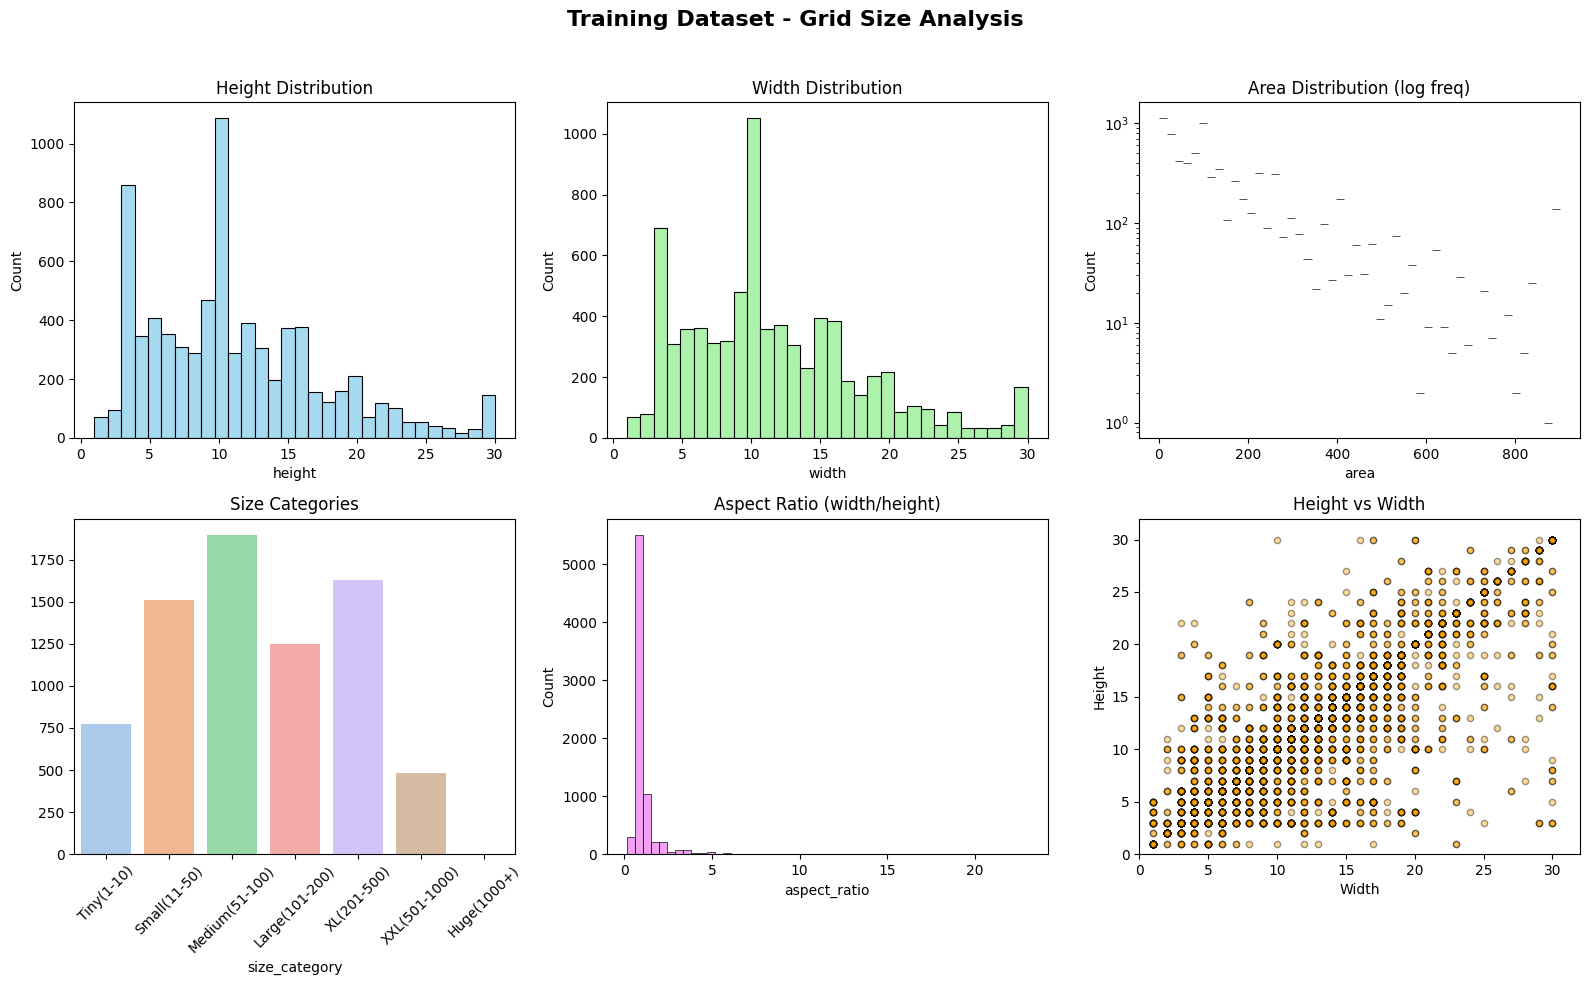

In [5]:
def plot_grid_analysis(df, title="Grid Size Analysis"):
    """Plot multiple aspects of grid sizes"""
    fig, axes = plt.subplots(2, 3, figsize=(16,10))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # 1. Height distribution
    sns.histplot(df['height'], bins=30, kde=False, ax=axes[0,0], color='skyblue')
    axes[0,0].set_title('Height Distribution')

    # 2. Width distribution
    sns.histplot(df['width'], bins=30, kde=False, ax=axes[0,1], color='lightgreen')
    axes[0,1].set_title('Width Distribution')

    # 3. Area distribution (log scale)
    sns.histplot(df['area'], bins=50, log_scale=(False, True), ax=axes[0,2], color='salmon')
    axes[0,2].set_title('Area Distribution (log freq)')

    # 4. Size categories
    size_counts = df['size_category'].value_counts().sort_index()
    sns.barplot(x=size_counts.index, y=size_counts.values, ax=axes[1,0], palette='pastel')
    axes[1,0].set_title('Size Categories')
    axes[1,0].tick_params(axis='x', rotation=45)

    # 5. Aspect ratio
    sns.histplot(df['aspect_ratio'], bins=50, ax=axes[1,1], color='violet')
    axes[1,1].set_title('Aspect Ratio (width/height)')

    # 6. Scatter: height vs width
    axes[1,2].scatter(df['width'], df['height'], alpha=0.4, c='orange', edgecolors='black', s=20)
    axes[1,2].set_title('Height vs Width')
    axes[1,2].set_xlabel('Width')
    axes[1,2].set_ylabel('Height')
    axes[1,2].set_xlim(0, df['width'].max()+2)
    axes[1,2].set_ylim(0, df['height'].max()+2)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Plot for training grids
plot_grid_analysis(train_grids, "Training Dataset - Grid Size Analysis")

# Color/Symbol Analysis

In [6]:


sns.set(style="whitegrid")

# Terminal color codes
class C:
    HEADER = '\033[95m'
    BLUE   = '\033[94m'
    CYAN   = '\033[96m'
    GREEN  = '\033[92m'
    YELLOW = '\033[93m'
    RED    = '\033[91m'
    BOLD   = '\033[1m'
    END    = '\033[0m'

def analyze_colors(data_dict, name):
    """Analyze color/symbol distribution (0-9) and show colorful summaries"""
    color_counter = Counter()
    task_color_stats = []

    for task_id, task in data_dict.items():
        task_colors = set()

        for pair in task.get('train', []):
            for grid_type in ['input', 'output']:
                grid = pair.get(grid_type)
                if grid:
                    for row in grid:
                        for val in row:
                            color_counter[val] += 1
                            task_colors.add(val)

        for test_grid in task.get('test', []):
            grid = test_grid.get('input')
            if grid:
                for row in grid:
                    for val in row:
                        color_counter[val] += 1
                        task_colors.add(val)

        task_color_stats.append({
            'task_id': task_id,
            'num_colors': len(task_colors),
            'colors': task_colors
        })

    # Terminal summary
    print(f"\n{C.BOLD}{C.HEADER}{'='*50}{C.END}")
    print(f"{C.BOLD}{C.CYAN}{name.upper()} - COLOR ANALYSIS{C.END}")
    print(f"{C.BOLD}{C.HEADER}{'='*50}{C.END}")
    print(f"\nTotal color occurrences: {sum(color_counter.values()):,}")

    print(f"\n{C.BOLD}Color distribution (0-9):{C.END}")
    for color in range(10):
        count = color_counter[color]
        pct = 100 * count / sum(color_counter.values())
        bar = '█' * int(pct/2)
        print(f"  {C.BLUE}Color {color}:{C.END} {count:8,} ({pct:5.2f}%) {bar}")

    df_colors = pd.DataFrame(task_color_stats)
    print(f"\n{C.BOLD}Colors per task:{C.END}")
    print(f"  Min   : {df_colors['num_colors'].min()}")
    print(f"  Max   : {df_colors['num_colors'].max()}")
    print(f"  Mean  : {df_colors['num_colors'].mean():.2f}")
    print(f"  Median: {df_colors['num_colors'].median():.0f}")
    print(f"  Std   : {df_colors['num_colors'].std():.2f}")

    return color_counter, df_colors

# ------------------------
# Run analysis
# ------------------------
train_colors, train_task_colors = analyze_colors(data['train_challenges'], 'training')
eval_colors, eval_task_colors   = analyze_colors(data['eval_challenges'], 'evaluation')


TRAINING - COLOR ANALYSIS

Total color occurrences: 1,237,958

Color distribution (0-9):
  Color 0:  632,736 (51.11%) █████████████████████████
  Color 1:   99,657 ( 8.05%) ████
  Color 2:   75,741 ( 6.12%) ███
  Color 3:   71,764 ( 5.80%) ██
  Color 4:   64,782 ( 5.23%) ██
  Color 5:   47,254 ( 3.82%) █
  Color 6:   28,615 ( 2.31%) █
  Color 7:   78,457 ( 6.34%) ███
  Color 8:  123,104 ( 9.94%) ████
  Color 9:   15,848 ( 1.28%) 

Colors per task:
  Min   : 2
  Max   : 10
  Mean  : 6.26
  Median: 6
  Std   : 2.34

EVALUATION - COLOR ANALYSIS

Total color occurrences: 312,791

Color distribution (0-9):
  Color 0:   69,746 (22.30%) ███████████
  Color 1:   43,020 (13.75%) ██████
  Color 2:   21,573 ( 6.90%) ███
  Color 3:   25,049 ( 8.01%) ████
  Color 4:   33,412 (10.68%) █████
  Color 5:   12,125 ( 3.88%) █
  Color 6:   14,064 ( 4.50%) ██
  Color 7:   21,335 ( 6.82%) ███
  Color 8:   63,478 (20.29%) ██████████
  Color 9:    8,989 ( 2.87%) █

Colors per task:
  Min   : 2
  Max   : 10
 

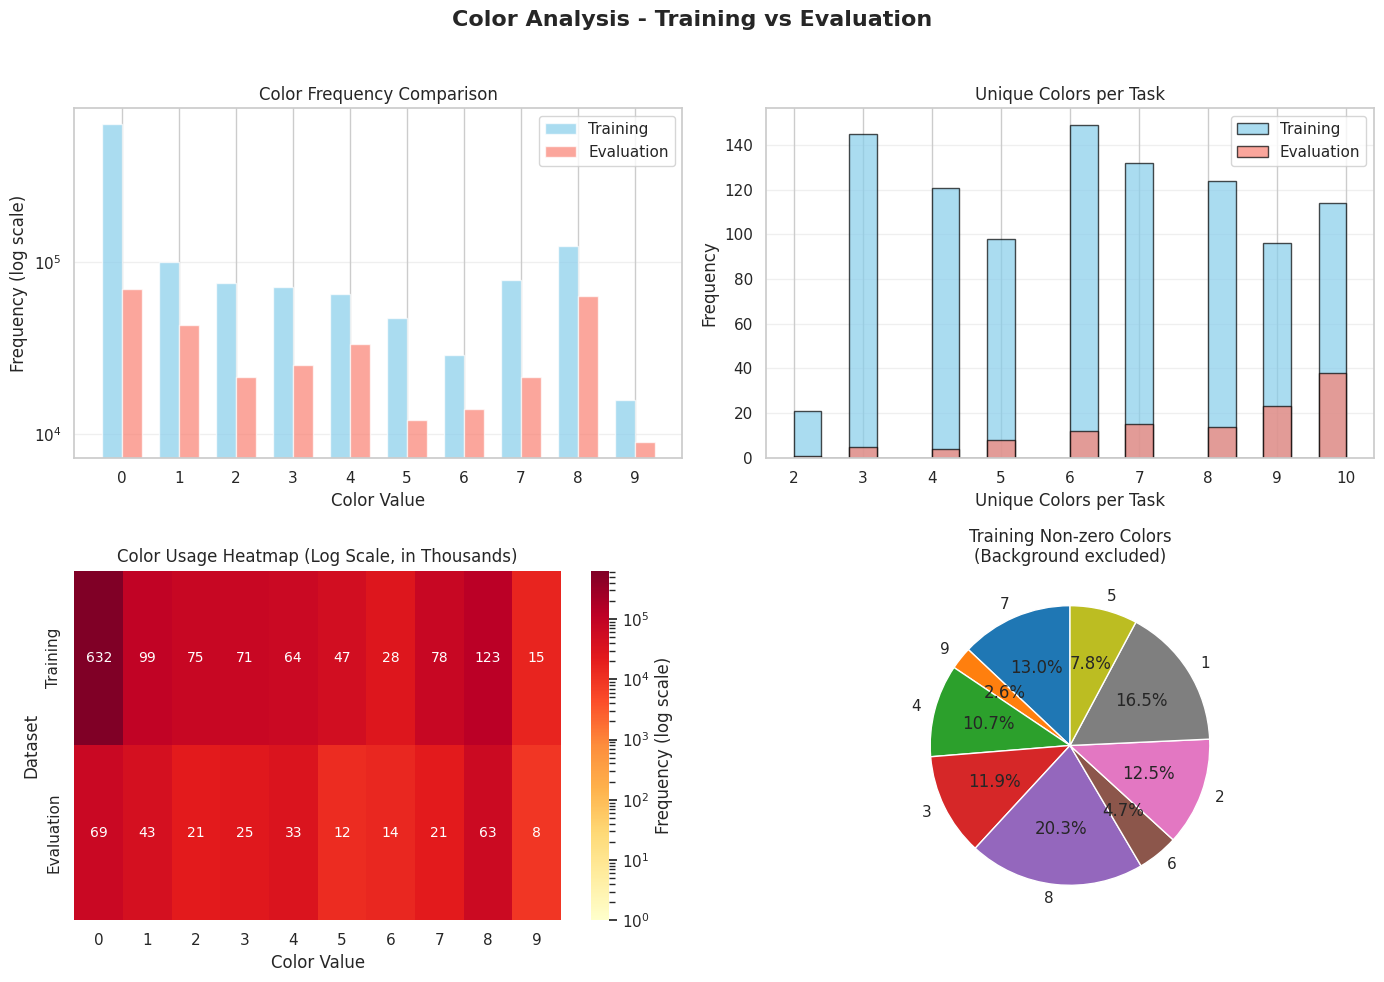

In [7]:

from matplotlib import colors as mcolors

colors = list(range(10))
x = np.arange(10)
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14,10))
plt.suptitle('Color Analysis - Training vs Evaluation', fontsize=16, fontweight='bold')


#  Color frequency comparison (log scale)

train_counts = [train_colors.get(i, 0) for i in colors]
eval_counts  = [eval_colors.get(i, 0) for i in colors]

axes[0,0].bar(x - width/2, train_counts, width, label='Training', alpha=0.7, color='skyblue')
axes[0,0].bar(x + width/2, eval_counts, width, label='Evaluation', alpha=0.7, color='salmon')
axes[0,0].set_xticks(x)
axes[0,0].set_xlabel('Color Value')
axes[0,0].set_ylabel('Frequency (log scale)')
axes[0,0].set_yscale('log')
axes[0,0].set_title('Color Frequency Comparison')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3, axis='y')


#  Unique colors per task distribution

axes[0,1].hist(train_task_colors['num_colors'], bins=20, alpha=0.7, label='Training',
               edgecolor='black', color='skyblue')
axes[0,1].hist(eval_task_colors['num_colors'], bins=20, alpha=0.7, label='Evaluation',
               edgecolor='black', color='salmon')
axes[0,1].set_xlabel('Unique Colors per Task')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Unique Colors per Task')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3, axis='y')


#  Color usage heatmap (log scale, scaled annotations)

color_matrix = np.array([train_counts, eval_counts])

# Scale down numbers for annotation to make them readable
annot_matrix = (color_matrix / 1000).astype(int)  # show in thousands

sns.heatmap(color_matrix, annot=annot_matrix, fmt='d', xticklabels=colors,
            yticklabels=['Training','Evaluation'], cmap='YlOrRd',
            norm=mcolors.LogNorm(vmin=1, vmax=max(color_matrix.max(), 1)),
            annot_kws={"fontsize":10},
            cbar_kws={'label':'Frequency (log scale)'}, ax=axes[1,0])
axes[1,0].set_title('Color Usage Heatmap (Log Scale, in Thousands)')
axes[1,0].set_xlabel('Color Value')
axes[1,0].set_ylabel('Dataset')


# Pie chart for non-zero colors

train_nonzero = {k:v for k,v in train_colors.items() if k != 0 and v > 0}
axes[1,1].pie(train_nonzero.values(), labels=train_nonzero.keys(),
              autopct='%1.1f%%', startangle=90, colors=sns.color_palette('tab10'))
axes[1,1].set_title('Training Non-zero Colors\n(Background excluded)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Input-Output Relationship Analysis

In [8]:
def analyze_input_output_relationships(data_dict, name):
    """Analyze how input and output grids relate"""
    relationships = []
    
    for task_id, task in data_dict.items():
        for pair_idx, pair in enumerate(task['train']):
            input_grid = pair['input']
            output_grid = pair['output']
            
            if not input_grid or not output_grid:
                continue
            
            in_h, in_w = len(input_grid), len(input_grid[0])
            out_h, out_w = len(output_grid), len(output_grid[0])
            
            # Size relationship
            height_ratio = out_h / in_h if in_h > 0 else 0
            width_ratio = out_w / in_w if in_w > 0 else 0
            area_ratio = (out_h * out_w) / (in_h * in_w) if (in_h * in_w) > 0 else 0
            
            # Unique colors
            in_colors = set()
            out_colors = set()
            for row in input_grid:
                in_colors.update(row)
            for row in output_grid:
                out_colors.update(row)
            
            relationships.append({
                'task_id': task_id,
                'pair_idx': pair_idx,
                'in_h': in_h,
                'in_w': in_w,
                'out_h': out_h,
                'out_w': out_w,
                'height_ratio': height_ratio,
                'width_ratio': width_ratio,
                'area_ratio': area_ratio,
                'size_changed': (in_h != out_h) or (in_w != out_w),
                'in_colors_count': len(in_colors),
                'out_colors_count': len(out_colors),
                'colors_preserved': len(in_colors.intersection(out_colors)) / max(len(in_colors), 1)
            })
    
    df = pd.DataFrame(relationships)
    
    
    print(f"{name.upper()} - INPUT/OUTPUT RELATIONSHIPS")
 
    print(f"\nSize changes:")
    print(f"  - Same size: {sum(~df['size_changed'])} ({100*sum(~df['size_changed'])/len(df):.1f}%)")
    print(f"  - Different size: {sum(df['size_changed'])} ({100*sum(df['size_changed'])/len(df):.1f}%)")
    
    print(f"\nHeight ratio distribution:")
    print(f"  - Min: {df['height_ratio'].min():.2f}")
    print(f"  - Max: {df['height_ratio'].max():.2f}")
    print(f"  - Mean: {df['height_ratio'].mean():.2f}")
    
    print(f"\nWidth ratio distribution:")
    print(f"  - Min: {df['width_ratio'].min():.2f}")
    print(f"  - Max: {df['width_ratio'].max():.2f}")
    print(f"  - Mean: {df['width_ratio'].mean():.2f}")
    
    print(f"\nColor preservation:")
    print(f"  - Mean preservation ratio: {df['colors_preserved'].mean():.2f}")
    print(f"  - Full preservation: {sum(df['colors_preserved'] == 1)} ({100*sum(df['colors_preserved'] == 1)/len(df):.1f}%)")
    
    return df


train_relationships = analyze_input_output_relationships(data['train_challenges'], 'training')
eval_relationships = analyze_input_output_relationships(data['eval_challenges'], 'evaluation')


TRAINING - INPUT/OUTPUT RELATIONSHIPS

Size changes:
  - Same size: 2114 (65.4%)
  - Different size: 1118 (34.6%)

Height ratio distribution:
  - Min: 0.04
  - Max: 15.00
  - Mean: 1.01

Width ratio distribution:
  - Min: 0.04
  - Max: 8.67
  - Mean: 0.99

Color preservation:
  - Mean preservation ratio: 0.85
  - Full preservation: 2117 (65.5%)
EVALUATION - INPUT/OUTPUT RELATIONSHIPS

Size changes:
  - Same size: 247 (69.0%)
  - Different size: 111 (31.0%)

Height ratio distribution:
  - Min: 0.10
  - Max: 3.40
  - Mean: 0.94

Width ratio distribution:
  - Min: 0.06
  - Max: 3.40
  - Mean: 0.91

Color preservation:
  - Mean preservation ratio: 0.87
  - Full preservation: 226 (63.1%)


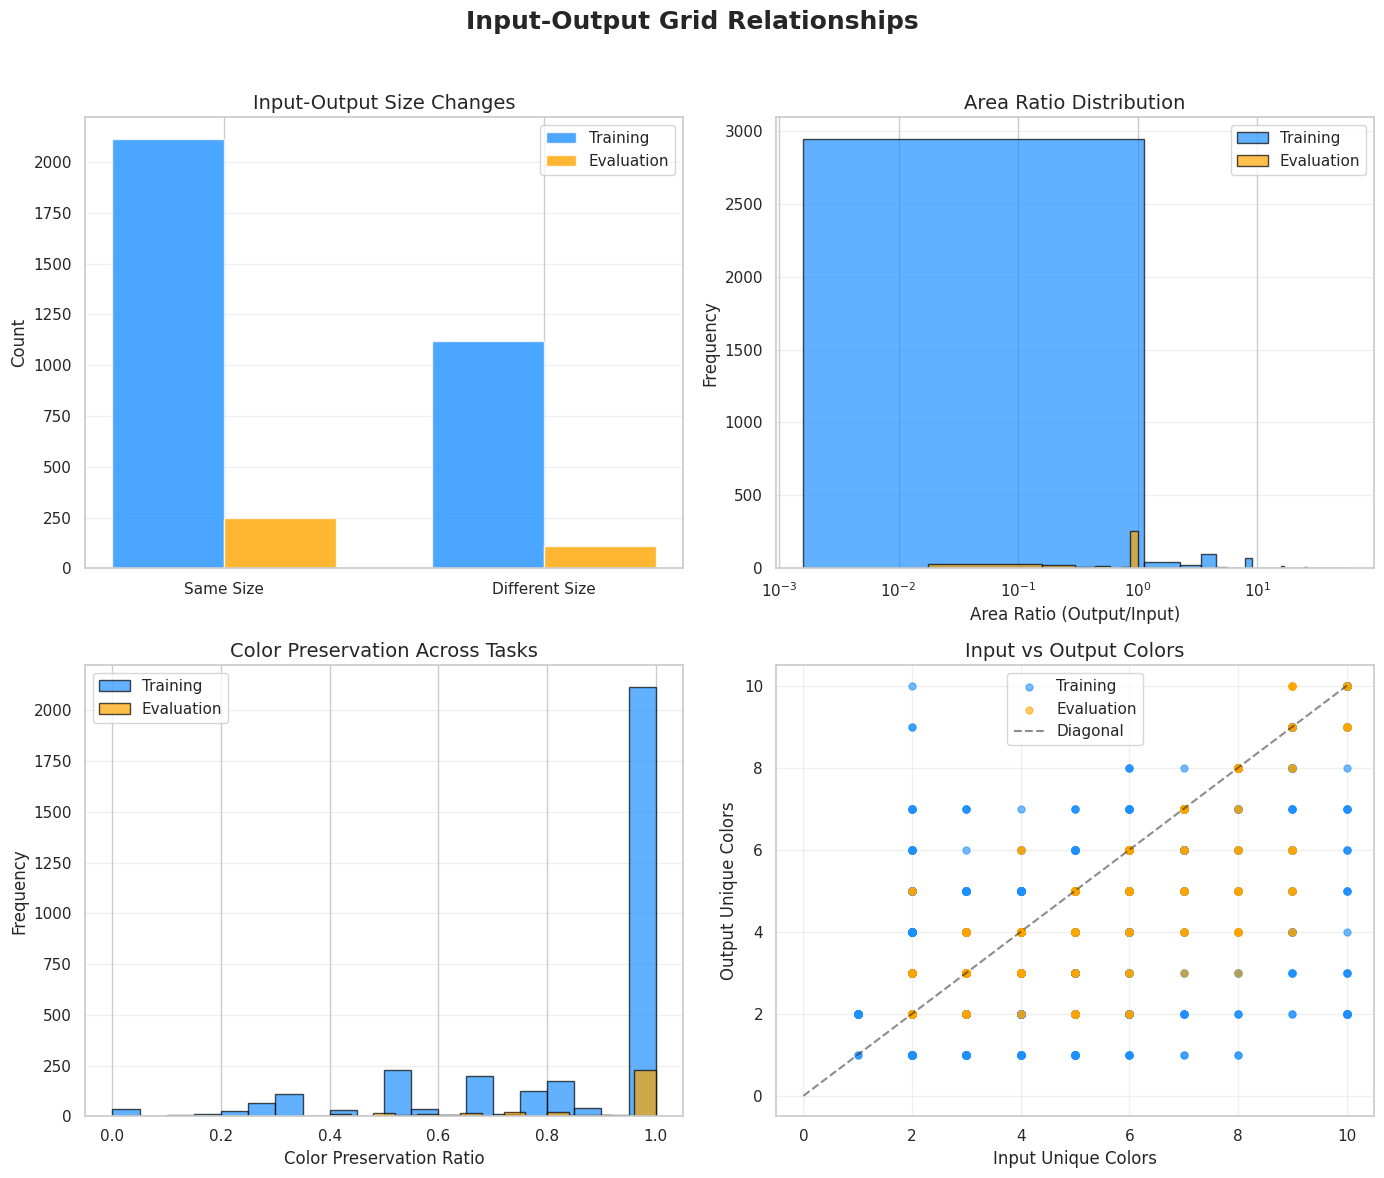


TRAINING SUMMARY
--------------------------------------------------
Size changed in 1118 out of 3232 pairs (34.6%)
Mean height ratio: 1.01
Mean width ratio: 0.99
Mean area ratio: 1.34
Mean color preservation: 0.85
Pairs with full color preservation: 2117 (65.5%)

EVALUATION SUMMARY
--------------------------------------------------
Size changed in 111 out of 358 pairs (31.0%)
Mean height ratio: 0.94
Mean width ratio: 0.91
Mean area ratio: 0.94
Mean color preservation: 0.87
Pairs with full color preservation: 226 (63.1%)


In [9]:

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plt.suptitle('Input-Output Grid Relationships', fontsize=18, fontweight='bold')

# Size Change Distribution
size_labels = ['Same Size', 'Different Size']
train_counts = [sum(~train_relationships['size_changed']), sum(train_relationships['size_changed'])]
eval_counts = [sum(~eval_relationships['size_changed']), sum(eval_relationships['size_changed'])]
x = np.arange(len(size_labels))
width = 0.35

axes[0,0].bar(x - width/2, train_counts, width, label='Training', alpha=0.8, color='dodgerblue')
axes[0,0].bar(x + width/2, eval_counts, width, label='Evaluation', alpha=0.8, color='orange')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(size_labels)
axes[0,0].set_ylabel('Count', fontsize=12)
axes[0,0].set_title('Input-Output Size Changes', fontsize=14)
axes[0,0].legend()
axes[0,0].grid(True, axis='y', alpha=0.3)

#  Area Ratio Distribution (Log Scale)
axes[0,1].hist(train_relationships['area_ratio'], bins=50, alpha=0.7, label='Training', edgecolor='black', color='dodgerblue')
axes[0,1].hist(eval_relationships['area_ratio'], bins=50, alpha=0.7, label='Evaluation', edgecolor='black', color='orange')
axes[0,1].set_xscale('log')
axes[0,1].set_xlabel('Area Ratio (Output/Input)', fontsize=12)
axes[0,1].set_ylabel('Frequency', fontsize=12)
axes[0,1].set_title('Area Ratio Distribution', fontsize=14)
axes[0,1].legend()
axes[0,1].grid(True, axis='y', alpha=0.3)

#  Color Preservation Ratio
axes[1,0].hist(train_relationships['colors_preserved'], bins=20, alpha=0.7, label='Training', edgecolor='black', color='dodgerblue')
axes[1,0].hist(eval_relationships['colors_preserved'], bins=20, alpha=0.7, label='Evaluation', edgecolor='black', color='orange')
axes[1,0].set_xlabel('Color Preservation Ratio', fontsize=12)
axes[1,0].set_ylabel('Frequency', fontsize=12)
axes[1,0].set_title('Color Preservation Across Tasks', fontsize=14)
axes[1,0].legend()
axes[1,0].grid(True, axis='y', alpha=0.3)

#  Input vs Output Unique Colors
axes[1,1].scatter(train_relationships['in_colors_count'], train_relationships['out_colors_count'],
                  alpha=0.6, s=25, label='Training', color='dodgerblue')
axes[1,1].scatter(eval_relationships['in_colors_count'], eval_relationships['out_colors_count'],
                  alpha=0.6, s=25, label='Evaluation', color='orange')
max_colors = max(train_relationships['in_colors_count'].max(), train_relationships['out_colors_count'].max(),
                 eval_relationships['in_colors_count'].max(), eval_relationships['out_colors_count'].max())
axes[1,1].plot([0, max_colors], [0, max_colors], 'k--', alpha=0.5, label='Diagonal')
axes[1,1].set_xlabel('Input Unique Colors', fontsize=12)
axes[1,1].set_ylabel('Output Unique Colors', fontsize=12)
axes[1,1].set_title('Input vs Output Colors', fontsize=14)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


#  SUMMARY STATISTICS 

def summarize_relationships(df, dataset_name):
    print(f"\n{dataset_name.upper()} SUMMARY")
    print("-"*50)
    print(f"Size changed in {sum(df['size_changed'])} out of {len(df)} pairs ({100*sum(df['size_changed'])/len(df):.1f}%)")
    print(f"Mean height ratio: {df['height_ratio'].mean():.2f}")
    print(f"Mean width ratio: {df['width_ratio'].mean():.2f}")
    print(f"Mean area ratio: {df['area_ratio'].mean():.2f}")
    print(f"Mean color preservation: {df['colors_preserved'].mean():.2f}")
    full_preserved = sum(df['colors_preserved'] == 1)
    print(f"Pairs with full color preservation: {full_preserved} ({100*full_preserved/len(df):.1f}%)")

summarize_relationships(train_relationships, "Training")
summarize_relationships(eval_relationships, "Evaluation")

# Pattern and Symmetry Analysis

In [10]:
def analyze_patterns(data_dict, name):
    """Analyze patterns, symmetries, and structure in grids"""
    patterns = []
    
    for task_id, task in data_dict.items():
        for pair_idx, pair in enumerate(task['train']):
            for grid_type in ['input', 'output']:
                grid = pair[grid_type]
                if not grid:
                    continue
                
                grid_array = np.array(grid)
                h, w = grid_array.shape
                
                # Check symmetries
                horizontal_sym = np.array_equal(grid_array, np.flipud(grid_array))
                vertical_sym = np.array_equal(grid_array, np.fliplr(grid_array))
                diagonal_sym = np.array_equal(grid_array, grid_array.T)
                
                # Check for constant rows/columns
                constant_rows = sum(1 for row in grid_array if len(set(row)) == 1)
                constant_cols = sum(1 for col in grid_array.T if len(set(col)) == 1)
                
                # Check for repeating patterns (simple periodicity)
                row_period = None
                for period in range(1, min(h, 10)):
                    if h % period == 0:
                        is_periodic = True
                        for i in range(period, h):
                            if not np.array_equal(grid_array[i], grid_array[i % period]):
                                is_periodic = False
                                break
                        if is_periodic:
                            row_period = period
                            break
                
                col_period = None
                for period in range(1, min(w, 10)):
                    if w % period == 0:
                        is_periodic = True
                        for j in range(period, w):
                            if not np.array_equal(grid_array[:, j], grid_array[:, j % period]):
                                is_periodic = False
                                break
                        if is_periodic:
                            col_period = period
                            break
                
                patterns.append({
                    'task_id': task_id,
                    'pair_idx': pair_idx,
                    'grid_type': grid_type,
                    'horizontal_sym': horizontal_sym,
                    'vertical_sym': vertical_sym,
                    'diagonal_sym': diagonal_sym,
                    'constant_rows': constant_rows,
                    'constant_cols': constant_cols,
                    'row_period': row_period,
                    'col_period': col_period,
                    'unique_values': len(np.unique(grid_array))
                })
    
    df = pd.DataFrame(patterns)
    
   
    print(f"{name.upper()} - PATTERN ANALYSIS")
    
    
    print(f"\nSymmetry occurrence:")
    print(f"  - Horizontal symmetry: {df['horizontal_sym'].sum()} ({100*df['horizontal_sym'].mean():.1f}%)")
    print(f"  - Vertical symmetry: {df['vertical_sym'].sum()} ({100*df['vertical_sym'].mean():.1f}%)")
    print(f"  - Diagonal symmetry: {df['diagonal_sym'].sum()} ({100*df['diagonal_sym'].mean():.1f}%)")
    
    print(f"\nPeriodicity:")
    row_periods = df[df['row_period'].notna()]['row_period'].value_counts()
    col_periods = df[df['col_period'].notna()]['col_period'].value_counts()
    print(f"  - Rows with periodic pattern: {df['row_period'].notna().sum()} ({100*df['row_period'].notna().mean():.1f}%)")
    print(f"  - Columns with periodic pattern: {df['col_period'].notna().sum()} ({100*df['col_period'].notna().mean():.1f}%)")
    if len(row_periods) > 0:
        print(f"  - Most common row period: {row_periods.index[0]} ({row_periods.iloc[0]} occurrences)")
    if len(col_periods) > 0:
        print(f"  - Most common col period: {col_periods.index[0]} ({col_periods.iloc[0]} occurrences)")
    
    return df

train_patterns = analyze_patterns(data['train_challenges'], 'training')
eval_patterns = analyze_patterns(data['eval_challenges'], 'evaluation')

TRAINING - PATTERN ANALYSIS

Symmetry occurrence:
  - Horizontal symmetry: 543 (8.4%)
  - Vertical symmetry: 632 (9.8%)
  - Diagonal symmetry: 532 (8.2%)

Periodicity:
  - Rows with periodic pattern: 154 (2.4%)
  - Columns with periodic pattern: 183 (2.8%)
  - Most common row period: 1.0 (95 occurrences)
  - Most common col period: 1.0 (104 occurrences)
EVALUATION - PATTERN ANALYSIS

Symmetry occurrence:
  - Horizontal symmetry: 34 (4.7%)
  - Vertical symmetry: 34 (4.7%)
  - Diagonal symmetry: 21 (2.9%)

Periodicity:
  - Rows with periodic pattern: 5 (0.7%)
  - Columns with periodic pattern: 6 (0.8%)
  - Most common row period: 1.0 (2 occurrences)
  - Most common col period: 1.0 (3 occurrences)


# Task Difficulty Analysis

In [11]:
def analyze_task_complexity(data_dict, solutions_dict, name):
    """Analyze task complexity metrics"""
    complexities = []
    
    for task_id, task in data_dict.items():
        if task_id not in solutions_dict:
            continue
            
        solution = solutions_dict[task_id]
        
        # Count test outputs
        num_test_outputs = len(solution)
        
        # Analyze train pairs complexity
        train_pair_complexities = []
        for pair in task['train']:
            input_grid = pair['input']
            output_grid = pair['output']
            
            if input_grid and output_grid:
                in_array = np.array(input_grid)
                out_array = np.array(output_grid)
                
                # Complexity metrics
                in_unique = len(np.unique(in_array))
                out_unique = len(np.unique(out_array))
                size_change = (in_array.shape != out_array.shape)
                
                train_pair_complexities.append({
                    'in_unique': in_unique,
                    'out_unique': out_unique,
                    'size_change': size_change,
                    'in_size': in_array.size,
                    'out_size': out_array.size
                })
        
        if train_pair_complexities:
            avg_in_unique = np.mean([c['in_unique'] for c in train_pair_complexities])
            avg_out_unique = np.mean([c['out_unique'] for c in train_pair_complexities])
            has_size_change = any(c['size_change'] for c in train_pair_complexities)
            
            complexities.append({
                'task_id': task_id,
                'num_train_pairs': len(task['train']),
                'num_test_outputs': num_test_outputs,
                'avg_in_unique_colors': avg_in_unique,
                'avg_out_unique_colors': avg_out_unique,
                'has_size_change': has_size_change,
                'color_complexity': avg_in_unique + avg_out_unique,
                'test_count': num_test_outputs
            })
    
    df = pd.DataFrame(complexities)
    
    
    print(f"{name.upper()} - TASK COMPLEXITY")
   
    
    print(f"\nNumber of test outputs per task:")
    print(f"  - Tasks with 1 test: {sum(df['num_test_outputs'] == 1)}")
    print(f"  - Tasks with 2 tests: {sum(df['num_test_outputs'] == 2)}")
    
    print(f"\nColor complexity (avg unique colors in + out):")
    print(f"  - Min: {df['color_complexity'].min():.1f}")
    print(f"  - Max: {df['color_complexity'].max():.1f}")
    print(f"  - Mean: {df['color_complexity'].mean():.1f}")
    print(f"  - Median: {df['color_complexity'].median():.1f}")
    
    print(f"\nSize change in transformations:")
    print(f"  - Tasks with size change: {df['has_size_change'].sum()} ({100*df['has_size_change'].mean():.1f}%)")
    print(f"  - Tasks without size change: {sum(~df['has_size_change'])} ({100*(1-df['has_size_change'].mean()):.1f}%)")
    
    return df

# Note: Solutions are needed for this analysis
train_complexity = analyze_task_complexity(data['train_challenges'], data['train_solutions'], 'training')
eval_complexity = analyze_task_complexity(data['eval_challenges'], data['eval_solutions'], 'evaluation')

TRAINING - TASK COMPLEXITY

Number of test outputs per task:
  - Tasks with 1 test: 931
  - Tasks with 2 tests: 63

Color complexity (avg unique colors in + out):
  - Min: 3.0
  - Max: 20.0
  - Mean: 7.6
  - Median: 7.0

Size change in transformations:
  - Tasks with size change: 320 (32.0%)
  - Tasks without size change: 680 (68.0%)
EVALUATION - TASK COMPLEXITY

Number of test outputs per task:
  - Tasks with 1 test: 71
  - Tasks with 2 tests: 46

Color complexity (avg unique colors in + out):
  - Min: 4.0
  - Max: 19.7
  - Mean: 9.9
  - Median: 9.8

Size change in transformations:
  - Tasks with size change: 39 (32.5%)
  - Tasks without size change: 81 (67.5%)


# Object and Structure Analysis

TRAINING - OBJECT ANALYSIS

Objects per grid:
  - Min: 1
  - Max: 841
  - Mean: 13.86
  - Median: 6

Object sizes:
  - Average size: 10.2 cells
  - Max object size: 37.0 cells
EVALUATION - OBJECT ANALYSIS

Objects per grid:
  - Min: 1
  - Max: 558
  - Mean: 26.77
  - Median: 11

Object sizes:
  - Average size: 21.4 cells
  - Max object size: 138.2 cells


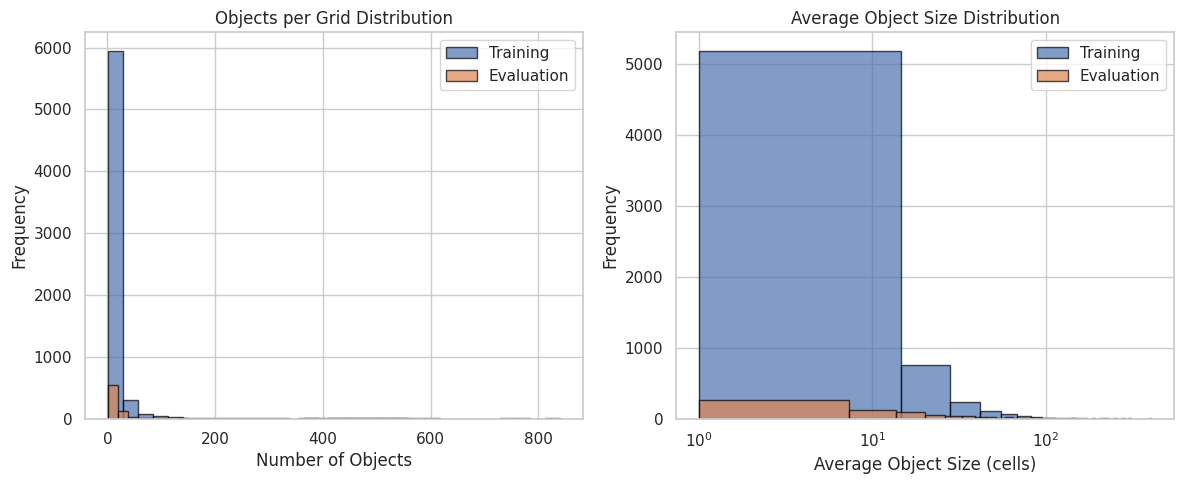

In [12]:
def find_connected_components(grid):
    """Find connected components (objects) in grid"""
    if not grid or len(grid) == 0:
        return 0, []
    
    grid_array = np.array(grid)
    h, w = grid_array.shape
    visited = np.zeros((h, w), dtype=bool)
    
    def dfs(r, c, color, component):
        if r < 0 or r >= h or c < 0 or c >= w:
            return
        if visited[r, c] or grid_array[r, c] != color:
            return
        visited[r, c] = True
        component.append((r, c))
        # 4-directional connectivity
        dfs(r+1, c, color, component)
        dfs(r-1, c, color, component)
        dfs(r, c+1, color, component)
        dfs(r, c-1, color, component)
    
    components = []
    for i in range(h):
        for j in range(w):
            if not visited[i, j] and grid_array[i, j] != 0:  # Ignore background (0)
                component = []
                dfs(i, j, grid_array[i, j], component)
                if component:
                    components.append(component)
    
    return len(components), components

def analyze_objects(data_dict, name):
    """Analyze objects and structures in grids"""
    object_stats = []
    
    for task_id, task in data_dict.items():
        for pair_idx, pair in enumerate(task['train']):
            for grid_type in ['input', 'output']:
                grid = pair[grid_type]
                if not grid:
                    continue
                
                num_components, components = find_connected_components(grid)
                
                if components:
                    sizes = [len(c) for c in components]
                    heights = [max(r for r,_ in c) - min(r for r,_ in c) + 1 for c in components]
                    widths = [max(c for _,c in c) - min(c for _,c in c) + 1 for c in components]
                    
                    object_stats.append({
                        'task_id': task_id,
                        'pair_idx': pair_idx,
                        'grid_type': grid_type,
                        'num_objects': num_components,
                        'avg_object_size': np.mean(sizes),
                        'max_object_size': max(sizes),
                        'min_object_size': min(sizes),
                        'avg_object_height': np.mean(heights),
                        'avg_object_width': np.mean(widths)
                    })
    
    df = pd.DataFrame(object_stats)
    
  
    print(f"{name.upper()} - OBJECT ANALYSIS")
  
    print(f"\nObjects per grid:")
    print(f"  - Min: {df['num_objects'].min()}")
    print(f"  - Max: {df['num_objects'].max()}")
    print(f"  - Mean: {df['num_objects'].mean():.2f}")
    print(f"  - Median: {df['num_objects'].median():.0f}")
    
    print(f"\nObject sizes:")
    print(f"  - Average size: {df['avg_object_size'].mean():.1f} cells")
    print(f"  - Max object size: {df['max_object_size'].mean():.1f} cells")
    
    return df

train_objects = analyze_objects(data['train_challenges'], 'training')
eval_objects = analyze_objects(data['eval_challenges'], 'evaluation')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Objects per grid
axes[0].hist(train_objects['num_objects'], bins=30, alpha=0.7, label='Training', edgecolor='black')
axes[0].hist(eval_objects['num_objects'], bins=30, alpha=0.7, label='Evaluation', edgecolor='black')
axes[0].set_xlabel('Number of Objects')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Objects per Grid Distribution')
axes[0].legend()

# Average object size
axes[1].hist(train_objects['avg_object_size'], bins=30, alpha=0.7, label='Training', edgecolor='black')
axes[1].hist(eval_objects['avg_object_size'], bins=30, alpha=0.7, label='Evaluation', edgecolor='black')
axes[1].set_xlabel('Average Object Size (cells)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Average Object Size Distribution')
axes[1].legend()
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

# Transformation Type Analysis

TRAINING - TRANSFORMATION TYPES
  Complex Transformation   : 2000 ( 61.9%)
  Resize                   :  920 ( 28.5%)
  Crop                     :  198 (  6.1%)
  Color Mapping            :   84 (  2.6%)
  Identity                 :   10 (  0.3%)
  Rotation_180             :    7 (  0.2%)
  Horizontal Flip          :    5 (  0.2%)
  Vertical Flip            :    4 (  0.1%)
  Rotation_90              :    4 (  0.1%)
EVALUATION - TRANSFORMATION TYPES
  Complex Transformation   :  249 ( 69.6%)
  Resize                   :  105 ( 29.3%)
  Color Mapping            :    2 (  0.6%)
  Identity                 :    1 (  0.3%)
  Crop                     :    1 (  0.3%)


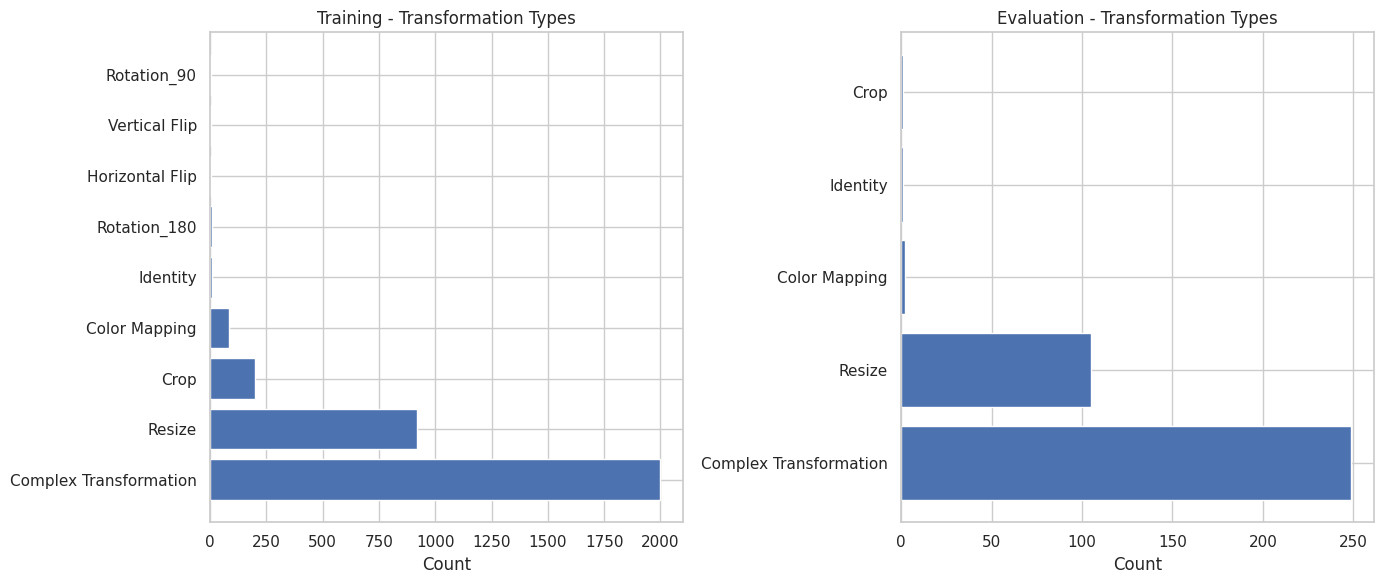

In [13]:
def classify_transformation(input_grid, output_grid):
    """Classify the type of transformation between input and output"""
    if not input_grid or not output_grid:
        return "Unknown"
    
    in_arr = np.array(input_grid)
    out_arr = np.array(output_grid)
    
    # Check for identity
    if in_arr.shape == out_arr.shape and np.array_equal(in_arr, out_arr):
        return "Identity"
    
    # Check for color mapping
    if in_arr.shape == out_arr.shape:
        color_map = {}
        is_color_map = True
        for i in range(in_arr.shape[0]):
            for j in range(in_arr.shape[1]):
                in_val = in_arr[i,j]
                out_val = out_arr[i,j]
                if in_val in color_map:
                    if color_map[in_val] != out_val:
                        is_color_map = False
                        break
                else:
                    color_map[in_val] = out_val
            if not is_color_map:
                break
        
        if is_color_map and len(color_map) > 0:
            return "Color Mapping"
    
    # Check for rotation
    for k in [1, 2, 3]:
        if out_arr.shape == np.rot90(in_arr, k).shape:
            if np.array_equal(out_arr, np.rot90(in_arr, k)):
                return f"Rotation_{k*90}"
    
    # Check for flip
    if out_arr.shape == np.fliplr(in_arr).shape:
        if np.array_equal(out_arr, np.fliplr(in_arr)):
            return "Horizontal Flip"
    if out_arr.shape == np.flipud(in_arr).shape:
        if np.array_equal(out_arr, np.flipud(in_arr)):
            return "Vertical Flip"
    
    # Check for crop/pad
    if in_arr.shape[0] >= out_arr.shape[0] and in_arr.shape[1] >= out_arr.shape[1]:
        # Check if output is a subgrid of input
        for i in range(in_arr.shape[0] - out_arr.shape[0] + 1):
            for j in range(in_arr.shape[1] - out_arr.shape[1] + 1):
                if np.array_equal(in_arr[i:i+out_arr.shape[0], j:j+out_arr.shape[1]], out_arr):
                    return "Crop"
    
    # Check for resize
    if in_arr.size != out_arr.size:
        return "Resize"
    
    return "Complex Transformation"

def analyze_transformations(data_dict, name):
    """Analyze transformation types in tasks"""
    transformations = []
    
    for task_id, task in data_dict.items():
        for pair_idx, pair in enumerate(task['train']):
            trans_type = classify_transformation(pair['input'], pair['output'])
            transformations.append({
                'task_id': task_id,
                'pair_idx': pair_idx,
                'transformation': trans_type
            })
    
    df = pd.DataFrame(transformations)
    trans_counts = df['transformation'].value_counts()
    
   
    print(f"{name.upper()} - TRANSFORMATION TYPES")
    
    
    for trans_type, count in trans_counts.items():
        pct = 100 * count / len(df)
        print(f"  {trans_type:25s}: {count:4d} ({pct:5.1f}%)")
    
    return df

train_transformations = analyze_transformations(data['train_challenges'], 'training')
eval_transformations = analyze_transformations(data['eval_challenges'], 'evaluation')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Transformation distribution - Training
train_counts = train_transformations['transformation'].value_counts()
axes[0].barh(range(len(train_counts)), train_counts.values)
axes[0].set_yticks(range(len(train_counts)))
axes[0].set_yticklabels(train_counts.index)
axes[0].set_xlabel('Count')
axes[0].set_title('Training - Transformation Types')

# Transformation distribution - Evaluation
eval_counts = eval_transformations['transformation'].value_counts()
axes[1].barh(range(len(eval_counts)), eval_counts.values)
axes[1].set_yticks(range(len(eval_counts)))
axes[1].set_yticklabels(eval_counts.index)
axes[1].set_xlabel('Count')
axes[1].set_title('Evaluation - Transformation Types')

plt.tight_layout()
plt.show()

In [14]:

from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Any
from sklearn.cluster import KMeans
from scipy.stats import ks_2samp, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Load data
def load_data():
    with open('/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_training_challenges.json', 'r') as f:
        train_challenges = json.load(f)
    with open('/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_training_solutions.json', 'r') as f:
        train_solutions = json.load(f)
    with open('/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_evaluation_challenges.json', 'r') as f:
        eval_challenges = json.load(f)
    with open('/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_evaluation_solutions.json', 'r') as f:
        eval_solutions = json.load(f)
    
    return train_challenges, train_solutions, eval_challenges, eval_solutions

train_challenges, train_solutions, eval_challenges, eval_solutions = load_data()

# Rule Consistency Per Task

In [15]:
def classify_advanced_transformation(input_grid, output_grid):
    """Advanced transformation classification"""
    if not input_grid or not output_grid:
        return "Unknown"
    
    in_arr = np.array(input_grid)
    out_arr = np.array(output_grid)
    in_h, in_w = in_arr.shape
    out_h, out_w = out_arr.shape
    
    # Identity
    if in_arr.shape == out_arr.shape and np.array_equal(in_arr, out_arr):
        return "Identity"
    
    # Color mapping
    if in_arr.shape == out_arr.shape:
        color_map = {}
        is_color_map = True
        for i in range(in_h):
            for j in range(in_w):
                in_val = in_arr[i,j]
                out_val = out_arr[i,j]
                if in_val in color_map:
                    if color_map[in_val] != out_val:
                        is_color_map = False
                        break
                else:
                    color_map[in_val] = out_val
            if not is_color_map:
                break
        
        if is_color_map and len(color_map) > 0:
            return "Color Mapping"
    
    # Rotations
    for k in [1, 2, 3]:
        if out_arr.shape == np.rot90(in_arr, k).shape:
            if np.array_equal(out_arr, np.rot90(in_arr, k)):
                return f"Rotation_{k*90}"
    
    # Flips
    if out_arr.shape == np.fliplr(in_arr).shape:
        if np.array_equal(out_arr, np.fliplr(in_arr)):
            return "Horizontal Flip"
    if out_arr.shape == np.flipud(in_arr).shape:
        if np.array_equal(out_arr, np.flipud(in_arr)):
            return "Vertical Flip"
    
    # Scaling (block repetition)
    if out_h % in_h == 0 and out_w % in_w == 0:
        scale_h = out_h // in_h
        scale_w = out_w // in_w
        is_scaling = True
        for i in range(out_h):
            for j in range(out_w):
                if out_arr[i,j] != in_arr[i // scale_h, j // scale_w]:
                    is_scaling = False
                    break
            if not is_scaling:
                break
        if is_scaling:
            return f"Scaling_{scale_h}x{scale_w}"
    
    # Tiling
    if out_h % in_h == 0 or out_w % in_w == 0:
        # Check if output is tiled repetition
        tile_h = out_h // in_h if in_h > 0 else 1
        tile_w = out_w // in_w if in_w > 0 else 1
        is_tiling = True
        for i in range(out_h):
            for j in range(out_w):
                if out_arr[i,j] != in_arr[i % in_h, j % in_w]:
                    is_tiling = False
                    break
            if not is_tiling:
                break
        if is_tiling:
            return f"Tiling_{tile_h}x{tile_w}"
    
    # Crop
    if in_h >= out_h and in_w >= out_w:
        for i in range(in_h - out_h + 1):
            for j in range(in_w - out_w + 1):
                if np.array_equal(in_arr[i:i+out_h, j:j+out_w], out_arr):
                    return "Crop"
    
    # Complex transformation
    return "Complex"

def check_rule_consistency(data_dict, name):
    """Check if all train pairs follow the same rule"""
    consistent_tasks = []
    inconsistent_tasks = []
    rule_distribution = []
    
    for task_id, task in data_dict.items():
        transformations = []
        for pair in task['train']:
            t = classify_advanced_transformation(pair['input'], pair['output'])
            transformations.append(t)
        
        unique_rules = set(transformations)
        is_consistent = len(unique_rules) == 1
        
        if is_consistent:
            consistent_tasks.append(task_id)
        else:
            inconsistent_tasks.append(task_id)
        
        rule_distribution.append({
            'task_id': task_id,
            'is_consistent': is_consistent,
            'num_unique_rules': len(unique_rules),
            'rules': transformations,
            'primary_rule': transformations[0] if transformations else None
        })
    
 
    print(f"{name.upper()} - RULE CONSISTENCY ANALYSIS")

    print(f"Consistent tasks: {len(consistent_tasks)}/{len(data_dict)} ({100*len(consistent_tasks)/len(data_dict):.1f}%)")
    print(f"Inconsistent tasks: {len(inconsistent_tasks)}/{len(data_dict)} ({100*len(inconsistent_tasks)/len(data_dict):.1f}%)")
    
    # Analyze multi-step tasks
    multi_step = []
    for task in rule_distribution:
        if not task['is_consistent']:
            multi_step.append({
                'task_id': task['task_id'],
                'rules': task['rules']
            })
    
    if multi_step:
        print(f"\nInconsistent tasks (potential multi-step logic):")
        for ms in multi_step[:5]:  # Show first 5
            print(f"  Task {ms['task_id']}: {ms['rules']}")
    
    return pd.DataFrame(rule_distribution)

train_consistency = check_rule_consistency(train_challenges, 'training')
eval_consistency = check_rule_consistency(eval_challenges, 'evaluation')

TRAINING - RULE CONSISTENCY ANALYSIS
Consistent tasks: 947/1000 (94.7%)
Inconsistent tasks: 53/1000 (5.3%)

Inconsistent tasks (potential multi-step logic):
  Task 12eac192: ['Complex', 'Complex', 'Color Mapping', 'Complex']
  Task 1fad071e: ['Complex', 'Crop', 'Complex']
  Task 22eb0ac0: ['Complex', 'Complex', 'Identity']
  Task 253bf280: ['Complex', 'Identity', 'Complex', 'Complex', 'Complex', 'Identity', 'Complex', 'Complex']
  Task 25d8a9c8: ['Complex', 'Color Mapping', 'Color Mapping', 'Color Mapping']
EVALUATION - RULE CONSISTENCY ANALYSIS
Consistent tasks: 117/120 (97.5%)
Inconsistent tasks: 3/120 (2.5%)

Inconsistent tasks (potential multi-step logic):
  Task 332f06d7: ['Color Mapping', 'Complex', 'Complex', 'Color Mapping']
  Task b6f77b65: ['Identity', 'Complex', 'Complex', 'Complex', 'Complex']
  Task f931b4a8: ['Complex', 'Complex', 'Complex', 'Crop', 'Complex']


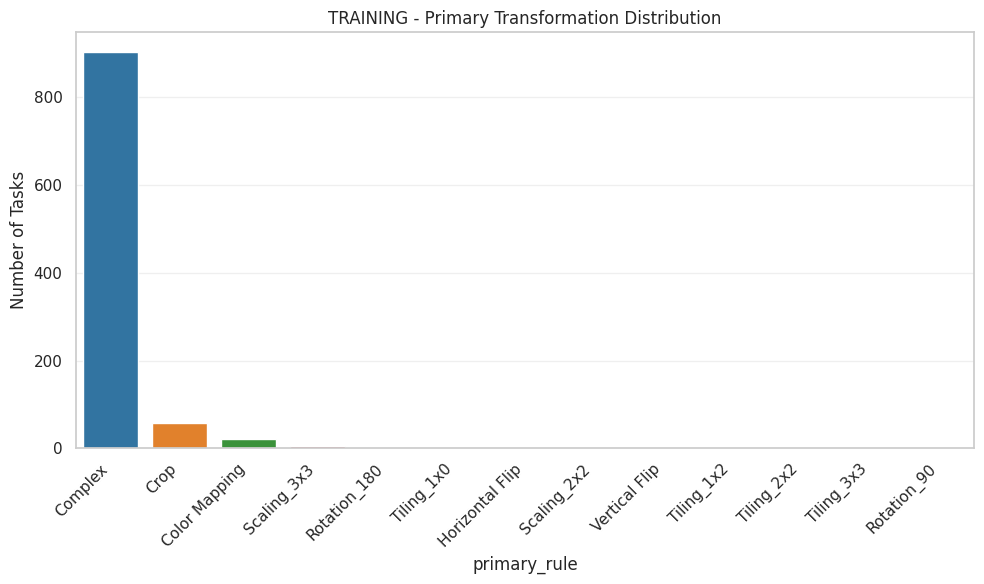

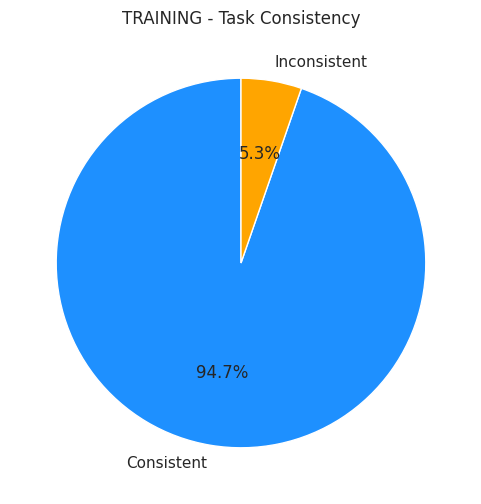

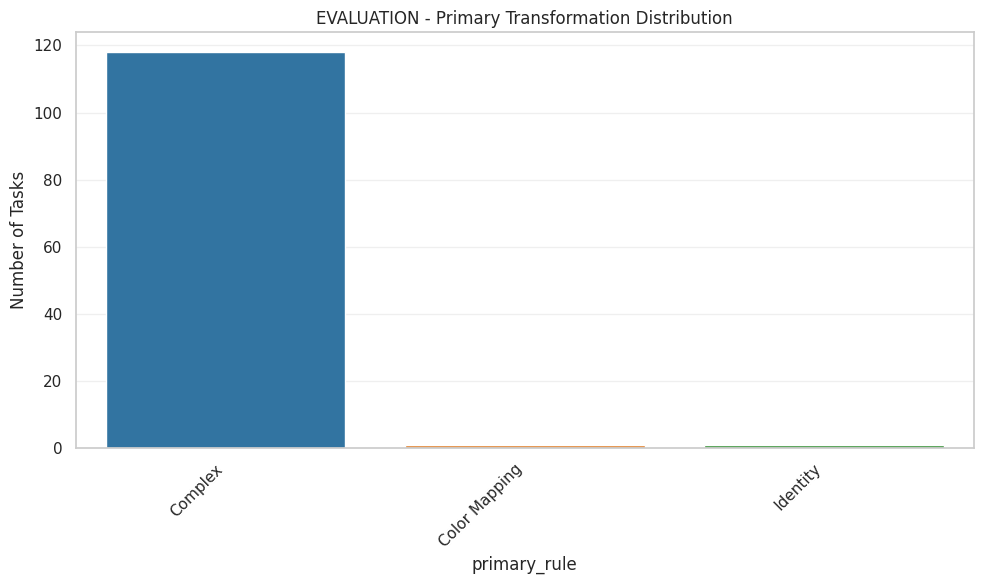

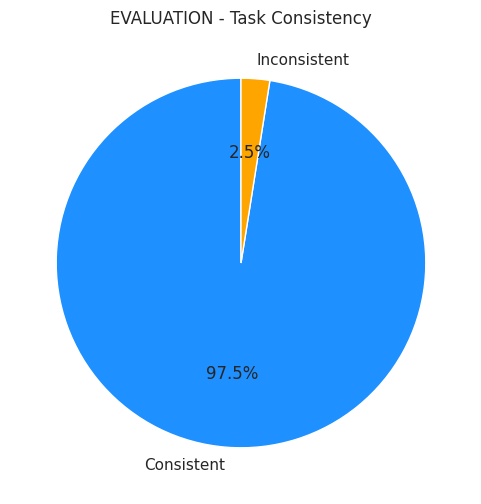

In [16]:

def plot_rule_distribution(df, dataset_name):
    """Visualize transformation distribution"""
    # Count occurrences of primary rules
    primary_counts = df['primary_rule'].value_counts()
    
    plt.figure(figsize=(10,6))
    sns.barplot(x=primary_counts.index, y=primary_counts.values, palette='tab10')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Number of Tasks')
    plt.title(f'{dataset_name.upper()} - Primary Transformation Distribution')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Pie chart for consistency
    consistency_counts = df['is_consistent'].value_counts()
    plt.figure(figsize=(6,6))
    plt.pie(consistency_counts.values, labels=['Consistent', 'Inconsistent'], autopct='%1.1f%%',
            colors=['dodgerblue','orange'], startangle=90)
    plt.title(f'{dataset_name.upper()} - Task Consistency')
    plt.show()

# Plot for training and evaluation sets
plot_rule_distribution(train_consistency, 'Training')
plot_rule_distribution(eval_consistency, 'Evaluation')

# Pixel-Level Change Analysis

In [17]:
def pixel_change_analysis(input_grid, output_grid):
    """Analyze pixel-level changes between input and output"""
    inp = np.array(input_grid)
    out = np.array(output_grid)
    
    if inp.shape != out.shape:
        return {
            'changed_pixels': None,
            'change_ratio': None,
            'unchanged_ratio': None,
            'different_shape': True,
            'in_shape': inp.shape,
            'out_shape': out.shape
        }
    
    diff = (inp != out)
    changed = diff.sum()
    total = inp.size
    
    # Analyze change patterns
    changed_positions = np.argwhere(diff)
    
    # What colors changed to what?
    color_changes = defaultdict(Counter)
    for i, j in changed_positions:
        color_changes[inp[i,j]][out[i,j]] += 1
    
    return {
        'changed_pixels': int(changed),
        'change_ratio': float(changed / total),
        'unchanged_ratio': float(1 - changed/total),
        'different_shape': False,
        'color_changes': dict(color_changes),
        'changed_positions': changed_positions.tolist()
    }

def analyze_all_pixel_changes(data_dict, name):
    """Apply pixel change analysis to all pairs"""
    pixel_stats = []
    
    for task_id, task in data_dict.items():
        for pair_idx, pair in enumerate(task['train']):
            stats = pixel_change_analysis(pair['input'], pair['output'])
            stats['task_id'] = task_id
            stats['pair_idx'] = pair_idx
            pixel_stats.append(stats)
    
    df = pd.DataFrame(pixel_stats)
    df_valid = df[df['different_shape'] == False]
    
    
    print(f"{name.upper()} - PIXEL CHANGE ANALYSIS")
   
    print(f"Pairs with shape change: {df['different_shape'].sum()} ({100*df['different_shape'].mean():.1f}%)")
    print(f"\nAmong same-shape pairs:")
    print(f"  - Avg changed pixels: {df_valid['changed_pixels'].mean():.1f}")
    print(f"  - Median changed pixels: {df_valid['changed_pixels'].median():.1f}")
    print(f"  - Avg change ratio: {df_valid['change_ratio'].mean():.3f} ({df_valid['change_ratio'].mean()*100:.1f}%)")
    
    # Categorize by change intensity
    df_valid['change_category'] = pd.cut(df_valid['change_ratio'], 
                                         bins=[0, 0.01, 0.1, 0.5, 1.0],
                                         labels=['Minimal(<1%)', 'Sparse(1-10%)', 'Moderate(10-50%)', 'Dense(>50%)'])
    
    print(f"\nChange intensity distribution:")
    for cat in ['Minimal(<1%)', 'Sparse(1-10%)', 'Moderate(10-50%)', 'Dense(>50%)']:
        count = (df_valid['change_category'] == cat).sum()
        if count > 0:
            print(f"  {cat}: {count} ({100*count/len(df_valid):.1f}%)")
    
    return df_valid

train_pixel = analyze_all_pixel_changes(train_challenges, 'training')
eval_pixel = analyze_all_pixel_changes(eval_challenges, 'evaluation')

TRAINING - PIXEL CHANGE ANALYSIS
Pairs with shape change: 1118 (34.6%)

Among same-shape pairs:
  - Avg changed pixels: 31.6
  - Median changed pixels: 17.5
  - Avg change ratio: 0.227 (22.7%)

Change intensity distribution:
  Minimal(<1%): 18 (0.9%)
  Sparse(1-10%): 684 (32.4%)
  Moderate(10-50%): 1201 (56.8%)
  Dense(>50%): 201 (9.5%)
EVALUATION - PIXEL CHANGE ANALYSIS
Pairs with shape change: 111 (31.0%)

Among same-shape pairs:
  - Avg changed pixels: 50.2
  - Median changed pixels: 32.0
  - Avg change ratio: 0.169 (16.9%)

Change intensity distribution:
  Minimal(<1%): 1 (0.4%)
  Sparse(1-10%): 114 (46.2%)
  Moderate(10-50%): 120 (48.6%)
  Dense(>50%): 11 (4.5%)


#  Position-Based Features (Bounding Boxes)

In [18]:
def get_bounding_box(grid):
    """Extract bounding box of non-zero elements"""
    arr = np.array(grid)
    non_zero = np.argwhere(arr != 0)
    
    if len(non_zero) == 0:
        return None
    
    rmin, cmin = non_zero.min(axis=0)
    rmax, cmax = non_zero.max(axis=0)
    
    return {
        'min_row': int(rmin),
        'min_col': int(cmin),
        'max_row': int(rmax),
        'max_col': int(cmax),
        'height': int(rmax - rmin + 1),
        'width': int(cmax - cmin + 1),
        'center_row': float((rmin + rmax) / 2),
        'center_col': float((cmin + cmax) / 2),
        'is_edge_touching': (rmin == 0 or rmax == arr.shape[0]-1 or 
                            cmin == 0 or cmax == arr.shape[1]-1)
    }

def analyze_position_features(data_dict, name):
    """Analyze position-based features and movements"""
    position_data = []
    
    for task_id, task in data_dict.items():
        for pair_idx, pair in enumerate(task['train']):
            input_bbox = get_bounding_box(pair['input'])
            output_bbox = get_bounding_box(pair['output'])
            
            if input_bbox and output_bbox:
                # Calculate movement
                row_shift = output_bbox['center_row'] - input_bbox['center_row']
                col_shift = output_bbox['center_col'] - input_bbox['center_col']
                
                position_data.append({
                    'task_id': task_id,
                    'pair_idx': pair_idx,
                    'input_center_row': input_bbox['center_row'],
                    'input_center_col': input_bbox['center_col'],
                    'output_center_row': output_bbox['center_row'],
                    'output_center_col': output_bbox['center_col'],
                    'row_shift': row_shift,
                    'col_shift': col_shift,
                    'absolute_shift': np.sqrt(row_shift**2 + col_shift**2),
                    'input_touches_edge': input_bbox['is_edge_touching'],
                    'output_touches_edge': output_bbox['is_edge_touching'],
                    'size_changed': (input_bbox['height'] != output_bbox['height'] or 
                                    input_bbox['width'] != output_bbox['width'])
                })
    
    df = pd.DataFrame(position_data)
    
  
    print(f"{name.upper()} - POSITION FEATURES")
  
    
    if len(df) > 0:
        print(f"\nObject movement:")
        print(f"  - Tasks with movement: {(df['absolute_shift'] > 0).sum()} ({100*(df['absolute_shift'] > 0).mean():.1f}%)")
        print(f"  - Average shift: {df['absolute_shift'].mean():.2f} cells")
        print(f"  - Max shift: {df['absolute_shift'].max():.2f} cells")
        
        print(f"\nEdge interaction:")
        print(f"  - Input touches edge: {df['input_touches_edge'].sum()} ({100*df['input_touches_edge'].mean():.1f}%)")
        print(f"  - Output touches edge: {df['output_touches_edge'].sum()} ({100*df['output_touches_edge'].mean():.1f}%)")
        
        print(f"\nSize changes in bounding box:")
        print(f"  - Bounding box size changed: {df['size_changed'].sum()} ({100*df['size_changed'].mean():.1f}%)")
    
    return df

train_position = analyze_position_features(train_challenges, 'training')
eval_position = analyze_position_features(eval_challenges, 'evaluation')

TRAINING - POSITION FEATURES

Object movement:
  - Tasks with movement: 1742 (54.2%)
  - Average shift: 2.19 cells
  - Max shift: 19.80 cells

Edge interaction:
  - Input touches edge: 2579 (80.3%)
  - Output touches edge: 2822 (87.8%)

Size changes in bounding box:
  - Bounding box size changed: 1798 (56.0%)
EVALUATION - POSITION FEATURES

Object movement:
  - Tasks with movement: 155 (43.3%)
  - Average shift: 2.66 cells
  - Max shift: 26.00 cells

Edge interaction:
  - Input touches edge: 335 (93.6%)
  - Output touches edge: 344 (96.1%)

Size changes in bounding box:
  - Bounding box size changed: 156 (43.6%)


# Object Movement Tracking

In [19]:
def find_connected_components_advanced(grid):
    """Find connected components with centroids"""
    if not grid or len(grid) == 0:
        return []
    
    grid_array = np.array(grid)
    h, w = grid_array.shape
    visited = np.zeros((h, w), dtype=bool)
    
    def dfs(r, c, color, component):
        if r < 0 or r >= h or c < 0 or c >= w:
            return
        if visited[r, c] or grid_array[r, c] != color:
            return
        visited[r, c] = True
        component.append((r, c))
        # 8-directional connectivity for object completeness
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                    continue
                dfs(r+dr, c+dc, color, component)
    
    components = []
    for i in range(h):
        for j in range(w):
            if not visited[i, j] and grid_array[i, j] != 0:
                component = []
                dfs(i, j, grid_array[i, j], component)
                if component:
                    centroid = np.mean(component, axis=0)
                    components.append({
                        'color': int(grid_array[i, j]),
                        'pixels': component,
                        'size': len(component),
                        'centroid_row': float(centroid[0]),
                        'centroid_col': float(centroid[1]),
                        'min_row': min(p[0] for p in component),
                        'max_row': max(p[0] for p in component),
                        'min_col': min(p[1] for p in component),
                        'max_col': max(p[1] for p in component)
                    })
    
    return components

def track_object_movement(data_dict, name):
    """Track how objects move between input and output"""
    movement_data = []
    
    for task_id, task in data_dict.items():
        for pair_idx, pair in enumerate(task['train']):
            input_components = find_connected_components_advanced(pair['input'])
            output_components = find_connected_components_advanced(pair['output'])
            
            # Simple matching by color and size
            for in_comp in input_components:
                best_match = None
                best_score = float('inf')
                
                for out_comp in output_components:
                    if in_comp['color'] == out_comp['color']:
                        # Score based on size difference and centroid distance
                        size_diff = abs(in_comp['size'] - out_comp['size'])
                        centroid_dist = np.sqrt((in_comp['centroid_row'] - out_comp['centroid_row'])**2 +
                                                (in_comp['centroid_col'] - out_comp['centroid_col'])**2)
                        score = size_diff + centroid_dist
                        
                        if score < best_score:
                            best_score = score
                            best_match = out_comp
                
                if best_match:
                    movement_data.append({
                        'task_id': task_id,
                        'pair_idx': pair_idx,
                        'color': in_comp['color'],
                        'size': in_comp['size'],
                        'input_centroid_row': in_comp['centroid_row'],
                        'input_centroid_col': in_comp['centroid_col'],
                        'output_centroid_row': best_match['centroid_row'],
                        'output_centroid_col': best_match['centroid_col'],
                        'row_shift': best_match['centroid_row'] - in_comp['centroid_row'],
                        'col_shift': best_match['centroid_col'] - in_comp['centroid_col'],
                        'size_changed': in_comp['size'] != best_match['size']
                    })
    
    df = pd.DataFrame(movement_data)
    
 
    print(f"{name.upper()} - OBJECT MOVEMENT TRACKING")
    
    
    if len(df) > 0:
        print(f"Tracked objects: {len(df)}")
        print(f"\nMovement patterns:")
        print(f"  - Objects that moved: {(df['row_shift'].abs() > 0) | (df['col_shift'].abs() > 0)}.sum()")
        print(f"  - Average shift: {np.sqrt(df['row_shift']**2 + df['col_shift']**2).mean():.2f} cells")
        print(f"  - Objects that changed size: {df['size_changed'].sum()} ({100*df['size_changed'].mean():.1f}%)")
        
        # Movement directions
        print(f"\nMovement directions:")
        print(f"  - Up: {(df['row_shift'] < 0).sum()} ({100*(df['row_shift'] < 0).mean():.1f}%)")
        print(f"  - Down: {(df['row_shift'] > 0).sum()} ({100*(df['row_shift'] > 0).mean():.1f}%)")
        print(f"  - Left: {(df['col_shift'] < 0).sum()} ({100*(df['col_shift'] < 0).mean():.1f}%)")
        print(f"  - Right: {(df['col_shift'] > 0).sum()} ({100*(df['col_shift'] > 0).mean():.1f}%)")
    
    return df

train_movement = track_object_movement(train_challenges, 'training')
eval_movement = track_object_movement(eval_challenges, 'evaluation')

TRAINING - OBJECT MOVEMENT TRACKING
Tracked objects: 27183

Movement patterns:
  - Objects that moved: 0        False
1        False
2        False
3        False
4        False
         ...  
27178     True
27179     True
27180     True
27181     True
27182     True
Length: 27183, dtype: bool.sum()
  - Average shift: 3.40 cells
  - Objects that changed size: 8204 (30.2%)

Movement directions:
  - Up: 8125 (29.9%)
  - Down: 3819 (14.0%)
  - Left: 7940 (29.2%)
  - Right: 3959 (14.6%)
EVALUATION - OBJECT MOVEMENT TRACKING
Tracked objects: 5193

Movement patterns:
  - Objects that moved: 0       True
1       True
2       True
3       True
4       True
        ... 
5188    True
5189    True
5190    True
5191    True
5192    True
Length: 5193, dtype: bool.sum()
  - Average shift: 5.04 cells
  - Objects that changed size: 1819 (35.0%)

Movement directions:
  - Up: 1680 (32.4%)
  - Down: 810 (15.6%)
  - Left: 1739 (33.5%)
  - Right: 769 (14.8%)


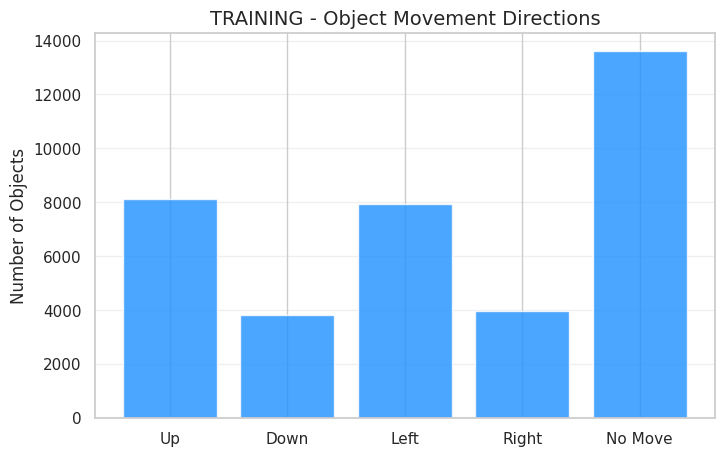

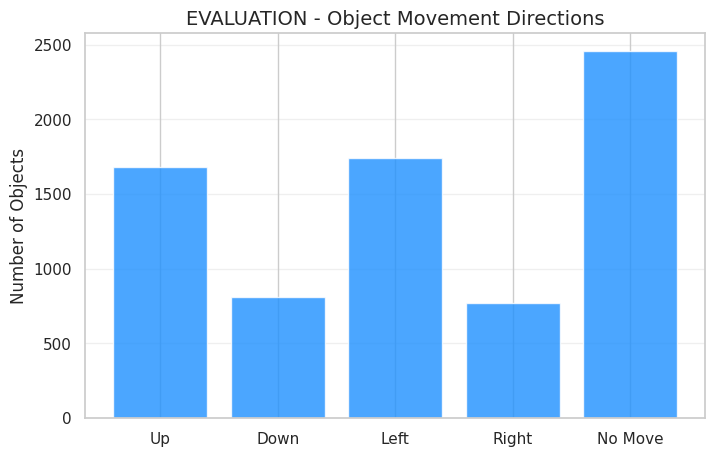

In [20]:
import matplotlib.pyplot as plt

def plot_movement_directions(df, dataset_name):
    directions = {
        'Up': (df['row_shift'] < 0).sum(),
        'Down': (df['row_shift'] > 0).sum(),
        'Left': (df['col_shift'] < 0).sum(),
        'Right': (df['col_shift'] > 0).sum(),
        'No Move': ((df['row_shift'] == 0) & (df['col_shift'] == 0)).sum()
    }
    
    plt.figure(figsize=(8,5))
    plt.bar(directions.keys(), directions.values(), color='dodgerblue', alpha=0.8)
    plt.title(f'{dataset_name.upper()} - Object Movement Directions', fontsize=14)
    plt.ylabel('Number of Objects')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

plot_movement_directions(train_movement, 'Training')
plot_movement_directions(eval_movement, 'Evaluation')

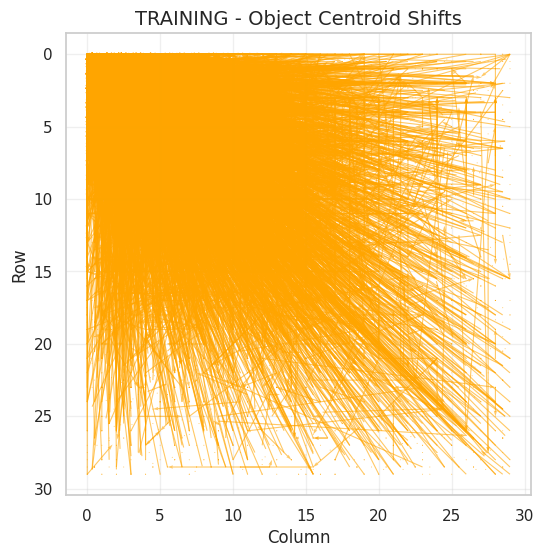

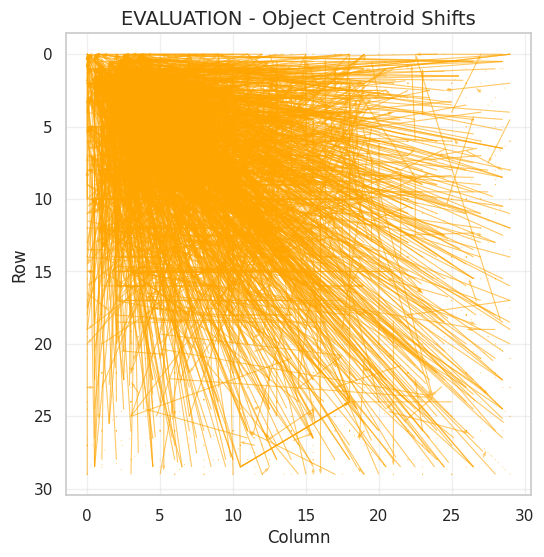

In [21]:
def plot_centroid_shifts(df, dataset_name):
    plt.figure(figsize=(6,6))
    plt.quiver(df['input_centroid_col'], df['input_centroid_row'], 
               df['col_shift'], df['row_shift'], angles='xy', scale_units='xy', scale=1,
               color='orange', alpha=0.6)
    plt.gca().invert_yaxis()  # Align with grid coordinates
    plt.title(f'{dataset_name.upper()} - Object Centroid Shifts', fontsize=14)
    plt.xlabel('Column')
    plt.ylabel('Row')
    plt.grid(True, alpha=0.3)
    plt.show()

plot_centroid_shifts(train_movement, 'Training')
plot_centroid_shifts(eval_movement, 'Evaluation')

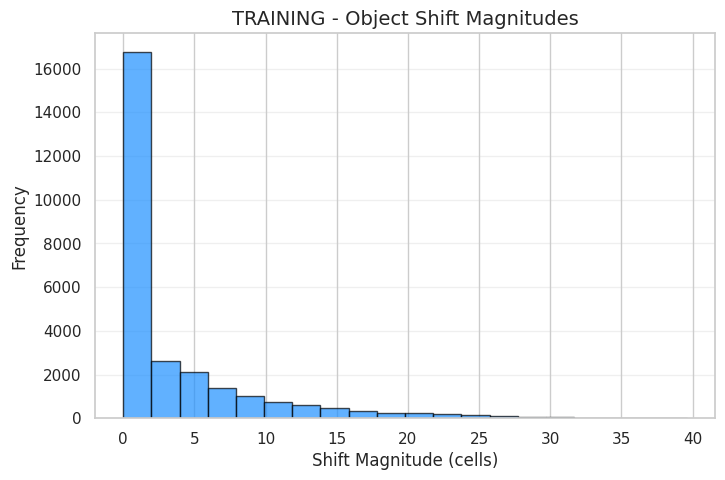

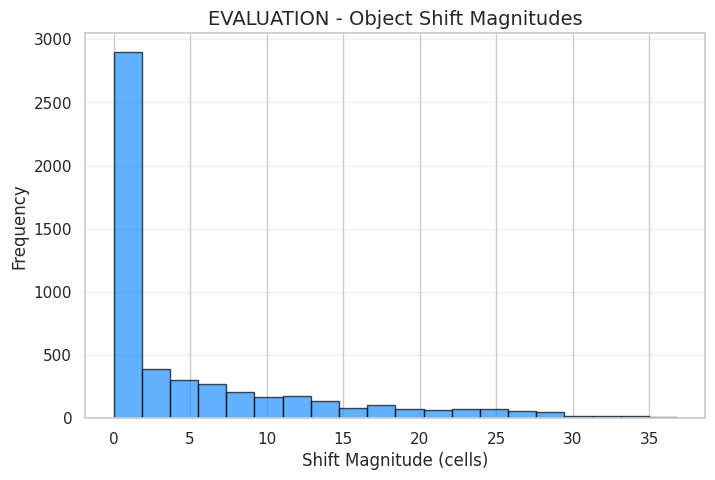

In [22]:
def plot_shift_magnitude(df, dataset_name):
    df['shift_magnitude'] = np.sqrt(df['row_shift']**2 + df['col_shift']**2)
    plt.figure(figsize=(8,5))
    plt.hist(df['shift_magnitude'], bins=20, alpha=0.7, color='dodgerblue', edgecolor='black')
    plt.title(f'{dataset_name.upper()} - Object Shift Magnitudes', fontsize=14)
    plt.xlabel('Shift Magnitude (cells)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

plot_shift_magnitude(train_movement, 'Training')
plot_shift_magnitude(eval_movement, 'Evaluation')

# Color Mapping Matrix

TRAINING - COLOR MAPPING MATRIX

Color mapping matrix (rows: input color, cols: output color):
     0  1  2  3  4  5  6  7  8  9
 0: 185313 4524 7341 9558 4890 1541 1851 2179 5794 434
 1: 701 22433 1123 680 468 140 213 302 672 135
 2: 794 602 16019 431 357 119 201 332 600 30
 3: 1103 368 288 13166 395 107 271 210 393 42
 4: 665 299 276 322 12569 125 143 142 195 36
 5: 566 546 526 283 371 10894 167 365 335 108
 6: 525 155 136 154 116 274 5961 186 241 60
 7: 655 424 451 333 339 574 293 22681 448 386
 8: 779 699 878 854 901 209 353 450 28118 296
 9: 206 94 46 43 70 80 67 251 116 2678

Most common color transformations:
  0 -> 3: 9558 occurrences
  0 -> 2: 7341 occurrences
  0 -> 8: 5794 occurrences
  0 -> 4: 4890 occurrences
  0 -> 1: 4524 occurrences
  0 -> 7: 2179 occurrences
  0 -> 6: 1851 occurrences
  0 -> 5: 1541 occurrences
  1 -> 2: 1123 occurrences
  3 -> 0: 1103 occurrences

Identity mappings: 998/2114 (47.2%)
EVALUATION - COLOR MAPPING MATRIX

Color mapping matrix (rows: input 

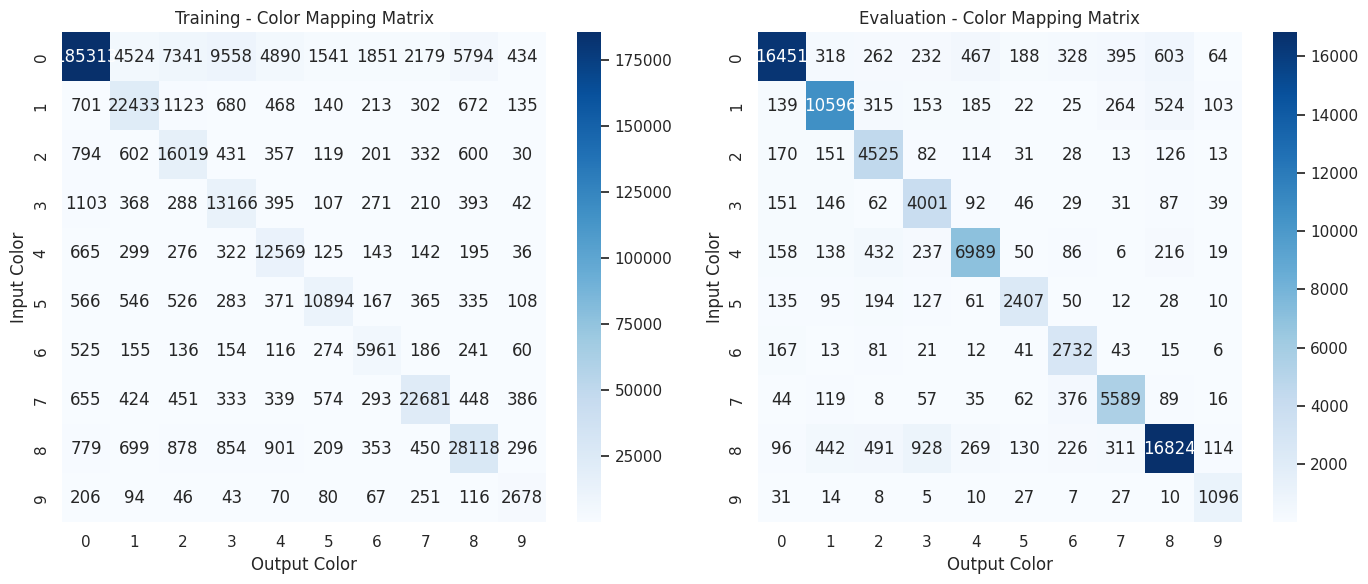

In [23]:
def extract_color_mapping_matrix(data_dict, name):
    """Extract and analyze color mapping patterns"""
    all_mappings = []
    mapping_matrix = np.zeros((10, 10), dtype=int)
    
    for task_id, task in data_dict.items():
        for pair in task['train']:
            inp = np.array(pair['input'])
            out = np.array(pair['output'])
            
            if inp.shape == out.shape:
                mapping = {}
                for i in range(inp.shape[0]):
                    for j in range(inp.shape[1]):
                        in_color = inp[i,j]
                        out_color = out[i,j]
                        mapping[in_color] = out_color
                        mapping_matrix[in_color, out_color] += 1
                
                all_mappings.append({
                    'task_id': task_id,
                    'mapping': mapping,
                    'is_identity': all(mapping.get(k, k) == k for k in range(10)),
                    'unique_mappings': len(set(mapping.values()))
                })
    
  
    print(f"{name.upper()} - COLOR MAPPING MATRIX")
  
    
    # Display mapping matrix
    print("\nColor mapping matrix (rows: input color, cols: output color):")
    print("    " + " ".join(f"{i:2d}" for i in range(10)))
    for i in range(10):
        row = mapping_matrix[i]
        if row.sum() > 0:
            print(f"{i:2d}: " + " ".join(f"{x:2d}" for x in row))
    
    # Most common mappings
    print("\nMost common color transformations:")
    mappings = []
    for i in range(10):
        for j in range(10):
            if i != j and mapping_matrix[i,j] > 0:
                mappings.append((i, j, mapping_matrix[i,j]))
    
    mappings.sort(key=lambda x: x[2], reverse=True)
    for i, j, count in mappings[:10]:
        print(f"  {i} -> {j}: {count} occurrences")
    
    # Identity mapping prevalence
    identity_count = sum(1 for m in all_mappings if m['is_identity'])
    print(f"\nIdentity mappings: {identity_count}/{len(all_mappings)} ({100*identity_count/len(all_mappings):.1f}%)")
    
    return mapping_matrix, pd.DataFrame(all_mappings)

train_color_matrix, train_color_mappings = extract_color_mapping_matrix(train_challenges, 'training')
eval_color_matrix, eval_color_mappings = extract_color_mapping_matrix(eval_challenges, 'evaluation')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(train_color_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Training - Color Mapping Matrix')
axes[0].set_xlabel('Output Color')
axes[0].set_ylabel('Input Color')

sns.heatmap(eval_color_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Evaluation - Color Mapping Matrix')
axes[1].set_xlabel('Output Color')
axes[1].set_ylabel('Input Color')

plt.tight_layout()
plt.show()

# More Transformations Detection

In [24]:
def detect_advanced_transformations(data_dict, name):
    """Detect advanced transformations including duplication and counting"""
    advanced_stats = []
    
    for task_id, task in data_dict.items():
        for pair_idx, pair in enumerate(task['train']):
            inp = np.array(pair['input'])
            out = np.array(pair['output'])
            
            # Object duplication detection
            in_objects = find_connected_components_advanced(pair['input'])
            out_objects = find_connected_components_advanced(pair['output'])
            
            # Check for duplication (more output objects of same color/size)
            duplication_detected = False
            for color in range(1, 10):
                in_count = sum(1 for obj in in_objects if obj['color'] == color)
                out_count = sum(1 for obj in out_objects if obj['color'] == color)
                if out_count > in_count and in_count > 0:
                    duplication_detected = True
                    break
            
            # Check for reflection + shift
            reflection_detected = False
            if inp.shape == out.shape:
                # Try horizontal reflection
                if np.array_equal(out, np.fliplr(inp)):
                    reflection_detected = True
                # Try vertical reflection
                elif np.array_equal(out, np.flipud(inp)):
                    reflection_detected = True
                # Try diagonal reflection
                elif np.array_equal(out, inp.T):
                    reflection_detected = True
            
            # Check for counting-based drawing
            counting_detected = False
            # Count objects in input and see if output has that many of something
            num_objects = len(in_objects)
            if num_objects > 0:
                # Check if output has num_objects of something
                unique_colors_in_out = len(set(out.flatten()) - {0})
                if unique_colors_in_out == num_objects:
                    counting_detected = True
            
            advanced_stats.append({
                'task_id': task_id,
                'pair_idx': pair_idx,
                'duplication_detected': duplication_detected,
                'reflection_detected': reflection_detected,
                'counting_detected': counting_detected,
                'num_input_objects': len(in_objects),
                'num_output_objects': len(out_objects)
            })
    
    df = pd.DataFrame(advanced_stats)
    
  
    print(f"{name.upper()} - ADVANCED TRANSFORMATIONS")
  
    print(f"Duplication detected: {df['duplication_detected'].sum()} ({100*df['duplication_detected'].mean():.1f}%)")
    print(f"Reflection detected: {df['reflection_detected'].sum()} ({100*df['reflection_detected'].mean():.1f}%)")
    print(f"Counting-based drawing: {df['counting_detected'].sum()} ({100*df['counting_detected'].mean():.1f}%)")
    
    return df

train_advanced = detect_advanced_transformations(train_challenges, 'training')
eval_advanced = detect_advanced_transformations(eval_challenges, 'evaluation')

TRAINING - ADVANCED TRANSFORMATIONS
Duplication detected: 902 (27.9%)
Reflection detected: 22 (0.7%)
Counting-based drawing: 782 (24.2%)
EVALUATION - ADVANCED TRANSFORMATIONS
Duplication detected: 169 (47.2%)
Reflection detected: 0 (0.0%)
Counting-based drawing: 34 (9.5%)


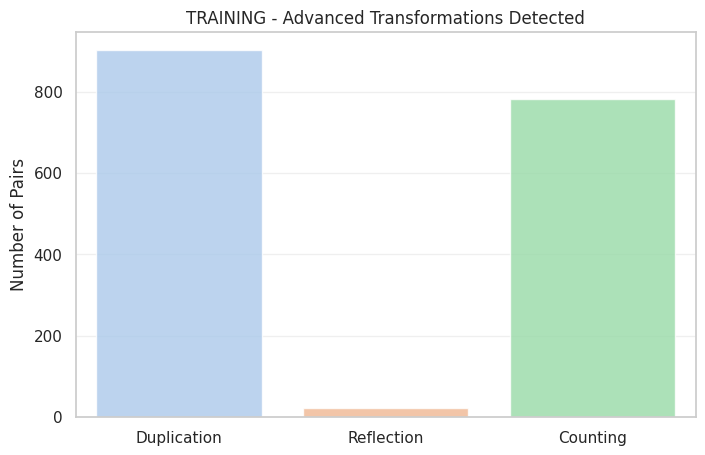

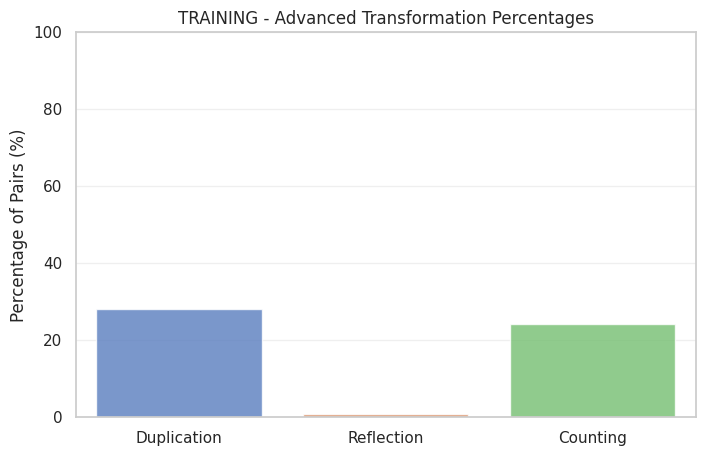

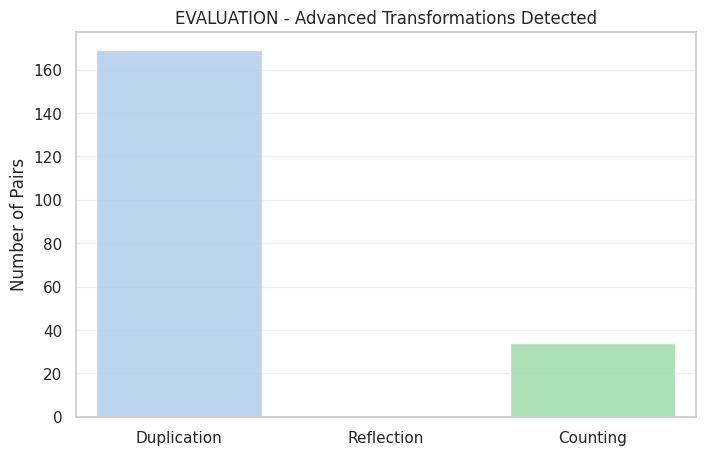

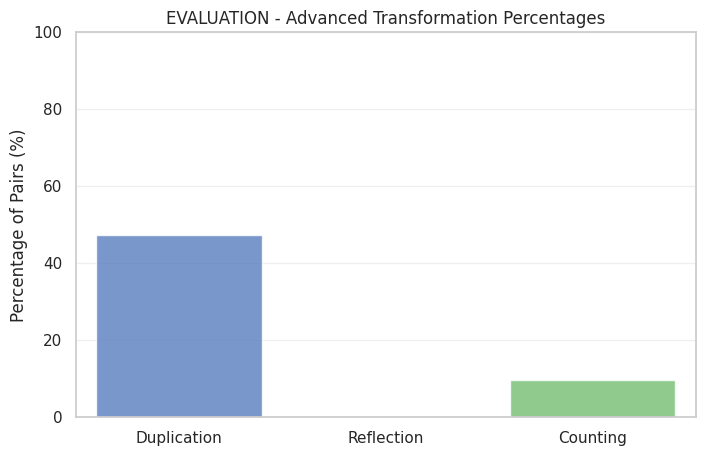

In [25]:

def plot_advanced_transformations(df, dataset_name):
    """Visualize counts of advanced transformations"""
    counts = {
        'Duplication': df['duplication_detected'].sum(),
        'Reflection': df['reflection_detected'].sum(),
        'Counting': df['counting_detected'].sum()
    }
    
    plt.figure(figsize=(8,5))
    sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='pastel', alpha=0.8)
    plt.ylabel('Number of Pairs')
    plt.title(f'{dataset_name.upper()} - Advanced Transformations Detected')
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
    # Percentage visualization
    percentages = [100*df[col].mean() for col in ['duplication_detected','reflection_detected','counting_detected']]
    plt.figure(figsize=(8,5))
    sns.barplot(x=list(counts.keys()), y=percentages, palette='muted', alpha=0.8)
    plt.ylabel('Percentage of Pairs (%)')
    plt.title(f'{dataset_name.upper()} - Advanced Transformation Percentages')
    plt.ylim(0,100)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Plot for training and evaluation
plot_advanced_transformations(train_advanced, 'Training')
plot_advanced_transformations(eval_advanced, 'Evaluation')

# Task Clustering

In [26]:
def cluster_tasks(data_dict, name):
    """Cluster tasks by their characteristics"""
    cluster_features = []
    
    for task_id, task in data_dict.items():
        # Extract features for this task
        size_changes = []
        color_preservations = []
        object_counts = []
        
        for pair in task['train']:
            inp = np.array(pair['input'])
            out = np.array(pair['output'])
            
            # Size ratio
            if inp.size > 0:
                size_changes.append(out.size / inp.size)
            
            # Color preservation
            in_colors = set(inp.flatten())
            out_colors = set(out.flatten())
            if len(in_colors) > 0:
                color_preservations.append(len(in_colors & out_colors) / len(in_colors))
            
            # Object counts
            in_objects = find_connected_components_advanced(pair['input'])
            out_objects = find_connected_components_advanced(pair['output'])
            object_counts.append(len(out_objects) - len(in_objects))
        
        cluster_features.append({
            'task_id': task_id,
            'avg_size_ratio': np.mean(size_changes) if size_changes else 1,
            'avg_color_preservation': np.mean(color_preservations) if color_preservations else 1,
            'avg_object_change': np.mean(object_counts) if object_counts else 0,
            'num_train_pairs': len(task['train'])
        })
    
    df = pd.DataFrame(cluster_features)
    
    # Perform clustering
    if len(df) >= 5:
        features_for_clustering = df[['avg_size_ratio', 'avg_color_preservation', 'avg_object_change']].fillna(0)
        kmeans = KMeans(n_clusters=min(5, len(df)), random_state=42, n_init=10)
        df['cluster'] = kmeans.fit_predict(features_for_clustering)
        
    
        print(f"{name.upper()} - TASK CLUSTERING")
        
        print(f"\nCluster distribution:")
        for cluster in sorted(df['cluster'].unique()):
            count = (df['cluster'] == cluster).sum()
            print(f"  Cluster {cluster}: {count} tasks ({100*count/len(df):.1f}%)")
            
            # Describe cluster
            cluster_data = df[df['cluster'] == cluster]
            print(f"    - Avg size ratio: {cluster_data['avg_size_ratio'].mean():.2f}")
            print(f"    - Avg color preservation: {cluster_data['avg_color_preservation'].mean():.2f}")
            print(f"    - Avg object change: {cluster_data['avg_object_change'].mean():.2f}")
    else:
        print(f"\nNot enough tasks for clustering in {name}")
        df['cluster'] = 0
    
    return df

train_clusters = cluster_tasks(train_challenges, 'training')
eval_clusters = cluster_tasks(eval_challenges, 'evaluation')

TRAINING - TASK CLUSTERING

Cluster distribution:
  Cluster 0: 96 tasks (9.6%)
    - Avg size ratio: 2.23
    - Avg color preservation: 0.94
    - Avg object change: 13.87
  Cluster 1: 6 tasks (0.6%)
    - Avg size ratio: 0.05
    - Avg color preservation: 0.58
    - Avg object change: -144.24
  Cluster 2: 821 tasks (82.1%)
    - Avg size ratio: 1.28
    - Avg color preservation: 0.88
    - Avg object change: 0.09
  Cluster 3: 65 tasks (6.5%)
    - Avg size ratio: 0.42
    - Avg color preservation: 0.65
    - Avg object change: -16.69
  Cluster 4: 12 tasks (1.2%)
    - Avg size ratio: 0.25
    - Avg color preservation: 0.57
    - Avg object change: -67.63
EVALUATION - TASK CLUSTERING

Cluster distribution:
  Cluster 0: 16 tasks (13.3%)
    - Avg size ratio: 0.63
    - Avg color preservation: 0.73
    - Avg object change: -12.28
  Cluster 1: 2 tasks (1.7%)
    - Avg size ratio: 0.02
    - Avg color preservation: 0.51
    - Avg object change: -164.50
  Cluster 2: 10 tasks (8.3%)
    - Av

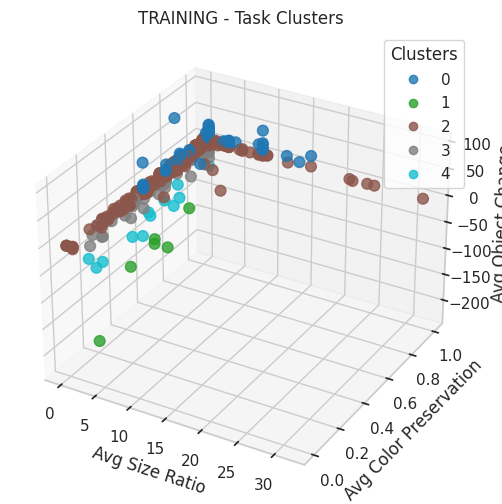

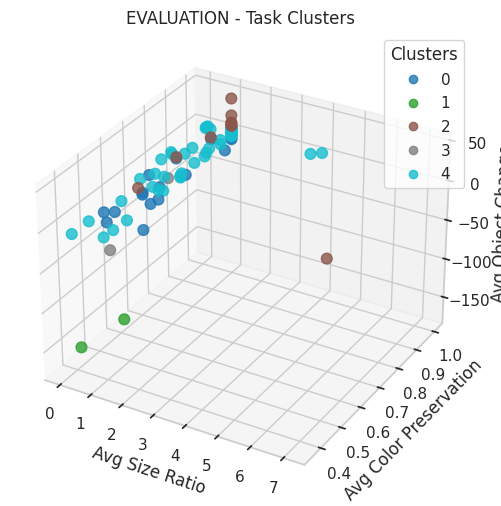

In [27]:
from mpl_toolkits.mplot3d import Axes3D


def plot_task_clusters(df, dataset_name):
    if 'cluster' not in df or df['cluster'].nunique() <= 1:
        print(f"No meaningful clusters to plot for {dataset_name}")
        return
    
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter(
        df['avg_size_ratio'], df['avg_color_preservation'], df['avg_object_change'],
        c=df['cluster'], cmap='tab10', s=60, alpha=0.8
    )
    
    ax.set_xlabel('Avg Size Ratio')
    ax.set_ylabel('Avg Color Preservation')
    ax.set_zlabel('Avg Object Change')
    ax.set_title(f'{dataset_name.upper()} - Task Clusters')
    plt.legend(*scatter.legend_elements(), title="Clusters")
    plt.show()

plot_task_clusters(train_clusters, 'Training')
plot_task_clusters(eval_clusters, 'Evaluation')

#  Train vs Eval Distribution Drift

DISTRIBUTION DRIFT ANALYSIS (Train vs Eval)

Kolmogorov-Smirnov tests for distribution similarity:
  area           : KS=0.4010, p=0.0000 [DRIFT DETECTED]
  height         : KS=0.3741, p=0.0000 [DRIFT DETECTED]
  width          : KS=0.4026, p=0.0000 [DRIFT DETECTED]
  unique_colors  : KS=0.3165, p=0.0000 [DRIFT DETECTED]

Chi-square tests:
  Size category distribution: chi2=27.11, p=0.1322 [Similar]


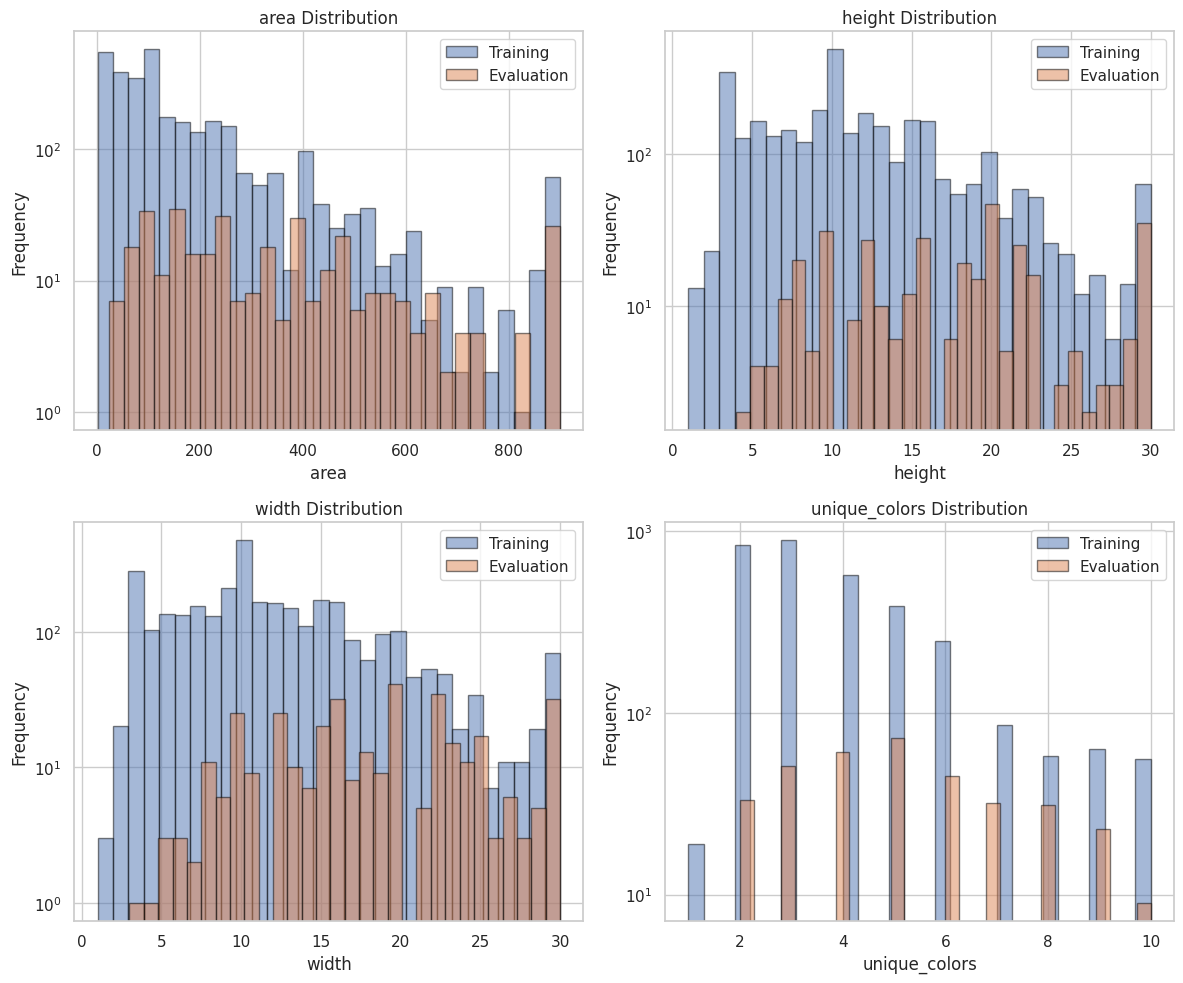

In [28]:
def detect_distribution_drift():
    """Statistical test for distribution shift between train and eval"""
    
    # Prepare features for comparison
    train_features = []
    eval_features = []
    
    for task_id, task in train_challenges.items():
        for pair in task['train']:
            inp = np.array(pair['input'])
            out = np.array(pair['output'])
            train_features.append({
                'area': inp.size,
                'height': inp.shape[0],
                'width': inp.shape[1],
                'unique_colors': len(np.unique(inp))
            })
    
    for task_id, task in eval_challenges.items():
        for pair in task['train']:
            inp = np.array(pair['input'])
            out = np.array(pair['output'])
            eval_features.append({
                'area': inp.size,
                'height': inp.shape[0],
                'width': inp.shape[1],
                'unique_colors': len(np.unique(inp))
            })
    
    train_df = pd.DataFrame(train_features)
    eval_df = pd.DataFrame(eval_features)
    
   
    print("DISTRIBUTION DRIFT ANALYSIS (Train vs Eval)")
    
    
    # Kolmogorov-Smirnov tests
    print("\nKolmogorov-Smirnov tests for distribution similarity:")
    for feature in ['area', 'height', 'width', 'unique_colors']:
        ks_stat, p_value = ks_2samp(train_df[feature], eval_df[feature])
        print(f"  {feature:15s}: KS={ks_stat:.4f}, p={p_value:.4f} {'[DRIFT DETECTED]' if p_value < 0.05 else '[Similar]'}")
    
    # Chi-square test for categorical features
    print("\nChi-square tests:")
    
    # Size categories
    train_size_cat = pd.cut(train_df['area'], bins=[0, 10, 50, 100, 200, 500, 1000, float('inf')])
    eval_size_cat = pd.cut(eval_df['area'], bins=[0, 10, 50, 100, 200, 500, 1000, float('inf')])
    
    contingency = pd.crosstab(train_size_cat, eval_size_cat)
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    print(f"  Size category distribution: chi2={chi2:.2f}, p={p_value:.4f} {'[DRIFT DETECTED]' if p_value < 0.05 else '[Similar]'}")
    
    # Visual comparison
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    features_to_plot = ['area', 'height', 'width', 'unique_colors']
    for idx, feature in enumerate(features_to_plot):
        ax = axes[idx//2, idx%2]
        ax.hist(train_df[feature], bins=30, alpha=0.5, label='Training', edgecolor='black')
        ax.hist(eval_df[feature], bins=30, alpha=0.5, label='Evaluation', edgecolor='black')
        ax.set_xlabel(feature)
        ax.set_ylabel('Frequency')
        ax.set_title(f'{feature} Distribution')
        ax.legend()
        ax.set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    return train_df, eval_df

train_dist, eval_dist = detect_distribution_drift()

# Test Input Pattern Matching

In [29]:
def analyze_test_pattern_matching(data_dict, solutions_dict, name):
    """Check if test input follows same pattern as train pairs"""
    pattern_match = []
    
    for task_id, task in data_dict.items():
        if task_id not in solutions_dict:
            continue
        
        # Get train pair characteristics
        train_patterns = []
        for pair in task['train']:
            train_patterns.append({
                'shape': np.array(pair['input']).shape,
                'unique_colors': len(np.unique(pair['input'])),
                'has_background': 0 in np.unique(pair['input'])
            })
        
        # Check test inputs
        for test_idx, test_input in enumerate(task['test']):
            test_arr = np.array(test_input['input'])
            test_features = {
                'shape': test_arr.shape,
                'unique_colors': len(np.unique(test_arr)),
                'has_background': 0 in np.unique(test_arr)
            }
            
            # Check consistency with train patterns
            shape_match = any(p['shape'] == test_features['shape'] for p in train_patterns)
            color_match = any(abs(p['unique_colors'] - test_features['unique_colors']) <= 1 for p in train_patterns)
            
            pattern_match.append({
                'task_id': task_id,
                'test_idx': test_idx,
                'shape_match': shape_match,
                'color_match': color_match,
                'overall_match': shape_match and color_match,
                'test_shape': test_features['shape'],
                'test_colors': test_features['unique_colors']
            })
    
    df = pd.DataFrame(pattern_match)
    
  
    print(f"{name.upper()} - TEST INPUT PATTERN MATCHING")
   
    print(f"Test inputs that match train patterns: {df['overall_match'].sum()}/{len(df)} ({100*df['overall_match'].mean():.1f}%)")
    print(f"Shape match: {df['shape_match'].sum()}/{len(df)} ({100*df['shape_match'].mean():.1f}%)")
    print(f"Color match: {df['color_match'].sum()}/{len(df)} ({100*df['color_match'].mean():.1f}%)")
    
    return df

train_pattern_match = analyze_test_pattern_matching(train_challenges, train_solutions, 'training')
eval_pattern_match = analyze_test_pattern_matching(eval_challenges, eval_solutions, 'evaluation')

TRAINING - TEST INPUT PATTERN MATCHING
Test inputs that match train patterns: 541/1076 (50.3%)
Shape match: 549/1076 (51.0%)
Color match: 1042/1076 (96.8%)
EVALUATION - TEST INPUT PATTERN MATCHING
Test inputs that match train patterns: 50/172 (29.1%)
Shape match: 57/172 (33.1%)
Color match: 148/172 (86.0%)


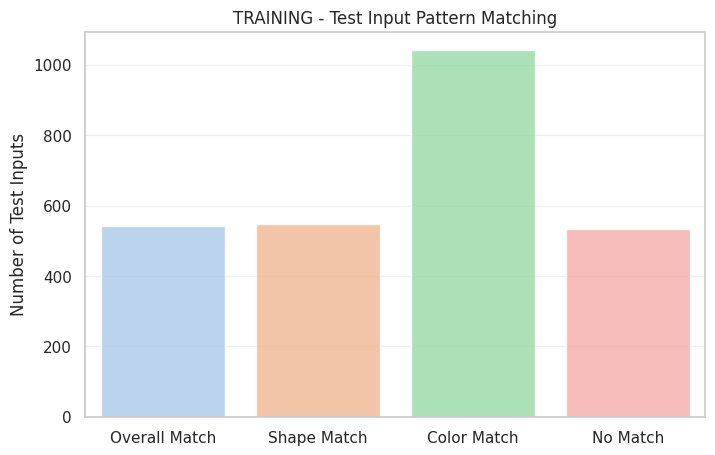

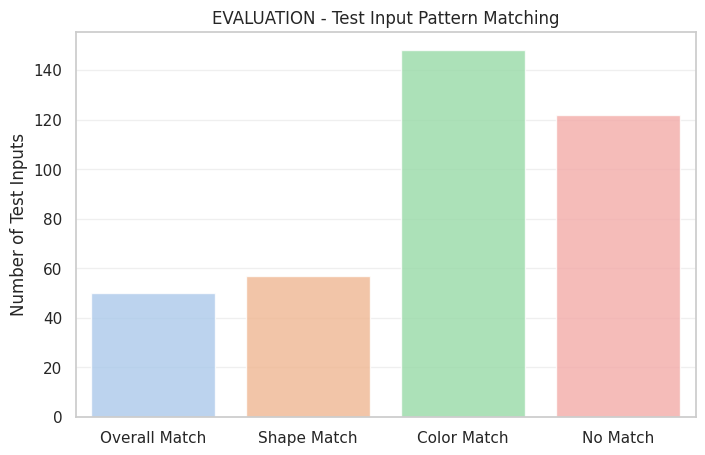

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_pattern_matching(df, dataset_name):
    counts = {
        'Overall Match': df['overall_match'].sum(),
        'Shape Match': df['shape_match'].sum(),
        'Color Match': df['color_match'].sum(),
        'No Match': (~df['overall_match']).sum()
    }

    plt.figure(figsize=(8,5))
    sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='pastel', alpha=0.8)
    plt.ylabel('Number of Test Inputs')
    plt.title(f'{dataset_name.upper()} - Test Input Pattern Matching')
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
# Visualize for training and evaluation
plot_pattern_matching(train_pattern_match, 'Training')
plot_pattern_matching(eval_pattern_match, 'Evaluation')

In [31]:
def pattern_mismatch_breakdown(df, dataset_name):
    shape_mismatch = df[~df['shape_match']]
    color_mismatch = df[~df['color_match']]
    
    print(f"{dataset_name.upper()} - Pattern Mismatch Details")
    print(f"Shape mismatches ({len(shape_mismatch)}):")
    print(shape_mismatch[['task_id','test_idx','test_shape']].head(10))
    
    print(f"\nColor mismatches ({len(color_mismatch)}):")
    print(color_mismatch[['task_id','test_idx','test_colors']].head(10))

pattern_mismatch_breakdown(train_pattern_match, 'Training')
pattern_mismatch_breakdown(eval_pattern_match, 'Evaluation')

TRAINING - Pattern Mismatch Details
Shape mismatches (527):
     task_id  test_idx test_shape
4   00dbd492         0   (20, 20)
6   025d127b         0   (10, 10)
13  0607ce86         0   (24, 22)
15  06df4c85         0   (26, 26)
16  070dd51e         0   (20, 20)
22  0a2355a6         0   (15, 17)
23  0a938d79         0   (11, 27)
24  0b148d64         0   (15, 17)
26  0bb8deee         0   (14, 13)
32  0d87d2a6         0   (23, 25)

Color mismatches (34):
      task_id  test_idx  test_colors
161  29c11459         0            5
196  33067df9         0            7
203  33b52de3         0            7
207  342dd610         0            5
275  458e3a53         0            7
298  4b6b68e5         0            8
329  52df9849         0            6
340  54dc2872         0            7
345  5587a8d0         0            7
347  5623160b         0            9
EVALUATION - Pattern Mismatch Details
Shape mismatches (115):
     task_id  test_idx test_shape
1   135a2760         0   (29, 29)
2   1

# Meta-Features Per Task 

In [32]:
def extract_meta_features(data_dict, solutions_dict, name):
    """Create one row per task with comprehensive meta-features"""
    meta_features = []
    
    for task_id, task in data_dict.items():
        # Rule consistency
        transformations = []
        for pair in task['train']:
            t = classify_advanced_transformation(pair['input'], pair['output'])
            transformations.append(t)
        rule_consistent = len(set(transformations)) == 1
        
        # Size changes
        size_changes = []
        color_changes = []
        object_count_changes = []
        
        for pair in task['train']:
            inp = np.array(pair['input'])
            out = np.array(pair['output'])
            
            size_changes.append(out.size != inp.size)
            
            in_colors = set(inp.flatten())
            out_colors = set(out.flatten())
            color_changes.append(len(in_colors - out_colors) / max(len(in_colors), 1))
            
            in_objects = len(find_connected_components_advanced(pair['input']))
            out_objects = len(find_connected_components_advanced(pair['output']))
            object_count_changes.append(out_objects - in_objects)
        
        # Symmetry usage
        has_symmetry = False
        for pair in task['train']:
            inp = np.array(pair['input'])
            out = np.array(pair['output'])
            if np.array_equal(out, np.fliplr(inp)) or np.array_equal(out, np.flipud(inp)):
                has_symmetry = True
                break
        
        # Test info
        num_test_inputs = len(task['test'])
        test_has_match = False
        if task_id in solutions_dict:
            test_has_match = True
        
        meta_features.append({
            'task_id': task_id,
            'num_train_pairs': len(task['train']),
            'num_test_inputs': num_test_inputs,
            'rule_consistent': rule_consistent,
            'primary_rule': transformations[0] if transformations else 'Unknown',
            'has_size_change': any(size_changes),
            'avg_color_change_ratio': np.mean(color_changes) if color_changes else 0,
            'avg_object_count_change': np.mean(object_count_changes) if object_count_changes else 0,
            'uses_symmetry': has_symmetry,
            'transformation_type': classify_advanced_transformation(
                task['train'][0]['input'], task['train'][0]['output']
            ) if task['train'] else 'Unknown',
            'has_test_solution': test_has_match
        })
    
    df = pd.DataFrame(meta_features)
    

    print(f"{name.upper()} - META-FEATURES PER TASK")
   
    print(f"\nSummary statistics:")
    print(f"  - Tasks with consistent rules: {df['rule_consistent'].sum()}/{len(df)} ({100*df['rule_consistent'].mean():.1f}%)")
    print(f"  - Tasks with size changes: {df['has_size_change'].sum()}/{len(df)} ({100*df['has_size_change'].mean():.1f}%)")
    print(f"  - Tasks using symmetry: {df['uses_symmetry'].sum()}/{len(df)} ({100*df['uses_symmetry'].mean():.1f}%)")
    
    print(f"\nPrimary transformation distribution:")
    trans_dist = df['transformation_type'].value_counts()
    for trans, count in trans_dist.head(10).items():
        print(f"  {trans}: {count} ({100*count/len(df):.1f}%)")
    
    return df

train_meta = extract_meta_features(train_challenges, train_solutions, 'training')
eval_meta = extract_meta_features(eval_challenges, eval_solutions, 'evaluation')

# Display meta-features table
print("\n" + "="*80)
print("META-FEATURES SAMPLE (First 10 training tasks)")
print("="*80)
display_cols = ['task_id', 'rule_consistent', 'has_size_change', 'uses_symmetry', 'transformation_type', 'num_test_inputs']
print(train_meta[display_cols].head(10).to_string())

TRAINING - META-FEATURES PER TASK

Summary statistics:
  - Tasks with consistent rules: 947/1000 (94.7%)
  - Tasks with size changes: 320/1000 (32.0%)
  - Tasks using symmetry: 9/1000 (0.9%)

Primary transformation distribution:
  Complex: 903 (90.3%)
  Crop: 58 (5.8%)
  Color Mapping: 21 (2.1%)
  Scaling_3x3: 4 (0.4%)
  Rotation_180: 3 (0.3%)
  Tiling_1x0: 2 (0.2%)
  Horizontal Flip: 2 (0.2%)
  Scaling_2x2: 2 (0.2%)
  Vertical Flip: 1 (0.1%)
  Tiling_1x2: 1 (0.1%)
EVALUATION - META-FEATURES PER TASK

Summary statistics:
  - Tasks with consistent rules: 117/120 (97.5%)
  - Tasks with size changes: 38/120 (31.7%)
  - Tasks using symmetry: 0/120 (0.0%)

Primary transformation distribution:
  Complex: 118 (98.3%)
  Color Mapping: 1 (0.8%)
  Identity: 1 (0.8%)

META-FEATURES SAMPLE (First 10 training tasks)
    task_id  rule_consistent  has_size_change  uses_symmetry transformation_type  num_test_inputs
0  00576224             True             True          False             Complex       

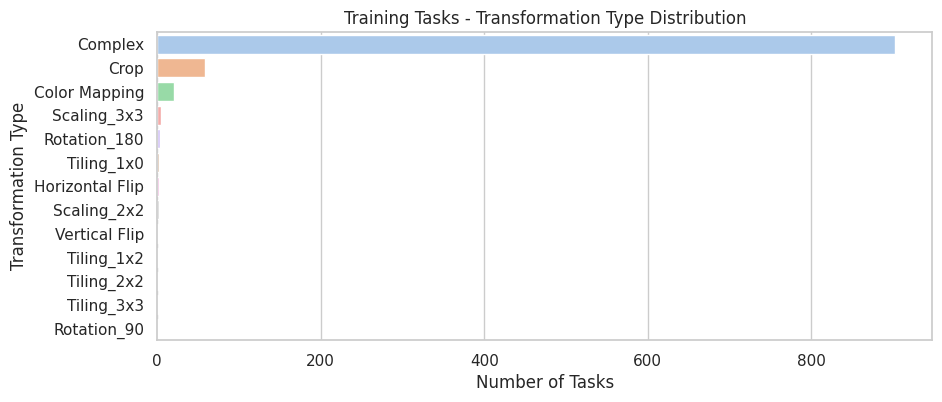

In [33]:


# Transformation type distribution
plt.figure(figsize=(10,4))
sns.countplot(y='transformation_type', data=train_meta, order=train_meta['transformation_type'].value_counts().index, palette='pastel')
plt.title('Training Tasks - Transformation Type Distribution')
plt.xlabel('Number of Tasks')
plt.ylabel('Transformation Type')
plt.show()

#  Dataset Summary & Analysis


---

### 1️⃣ Overview  

| Metric |   Training |   Evaluation |
| :--- | :--- | :--- |
| **Total tasks** | 1000 | 120 |
| **Total train pairs** | 3232 | 358 |
| **Total test inputs** | 1076 | 172 |
| **Train pairs per task** | 2–10 (mean 3.23) | 2–6 (mean 2.98) |
| **Test inputs per task** | 1–4 (mean 1.08) | 1–3 (mean 1.43) |

---

### 2️⃣ Grid Size Analysis  

####   Training Grids (Total: 7,540)
- **Height:** 1–30 (mean 11.03)
- **Width:** 1–30 (mean 11.53)
- **Area:** 1–900 (mean 164.2)

####   Evaluation Grids (Total: 888)
- **Height:** 2–30 (mean 17.41)
- **Width:** 1–30 (mean 17.95)
- **Area:** 10–900 (mean 352.2)

>   **Observation:** Evaluation grids are generally **significantly larger**, indicating a notable **distribution drift** between train and eval sets.

---

### 3️⃣ Color Analysis  

| Metric |   Training |   Evaluation |
| :--- | :--- | :--- |
| **Total color occurrences** | 1,237,958 | 312,791 |
| **Top colors** | 0 (51%), 8 (9.9%), 1 (8%) | 0 (22%), 8 (20%), 1 (13.8%) |
| **Colors per task** | 2–10 (mean 6.26) | 2–10 (mean 7.91) |
| **Mean color preservation** | 0.85 | 0.87 |
| **Full preservation** | 65.5% | 63.1% |

---

### 4️⃣ Input/Output Relationships 

| Property |   Training |   Evaluation |
| :--- | :--- | :--- |
| **Size changes** | 34% | 31% |
| **Height ratio** | 1.01 | 0.94 |
| **Width ratio** | 0.99 | 0.91 |
| **Mean color preservation** | 0.85–0.87 | — |
| **Full color preservation** | 63–65% | — |

---

### 5️⃣ Pattern & Symmetry 

- **Symmetry:** Present in **8–10%** of train objects, but only **2–5%** of eval objects.
- **Periodicity:** Rare (<3% of rows/columns).
- **Transformation Types:**
  -   Training: Complex (62%), Resize (28%), Crop (6%), Color Mapping (2.6%)
  -   Evaluation: Complex (70%), Resize (29%), Color Mapping (0.6%)

---

### 6️⃣ Task Complexity 

- **Test outputs per task:** Mostly 1.
- **Color complexity (avg unique colors):** 7.6 (train) vs. 9.9 (eval)
- **Tasks with size change:** ~32% across the board.

---

### 7️⃣ Object Analysis & Movement 

| Metric |   Training |   Evaluation |
| :--- | :--- | :--- |
| **Objects per grid** | 14 | 27 |
| **Average object size** | 10.2 | 21.4 |
| **Object movement** | 54% of tasks | 43% of tasks |
| **Avg movement shift** | 2.19 | 2.66 |
| **Dominant directions** |   Up &   Left |   Up &   Left |

---

### 8️⃣ Color Mapping 

- **Identity mappings:** 47% (train) vs. 42% (eval)
- **Top transformations (Training):** 0→3, 0→2, 0→8
- **Top transformations (Evaluation):** 8→3, 0→8, 1→8

---

### 9️⃣ Advanced Transformations 

| Transformation |   Training |   Evaluation |
| :--- | :--- | :--- |
| **Duplication** | 27.9% | 47.2% |
| **Counting-based drawing** | 24.2% | 9.5% |
| **Reflection** | 0.7% | 0% |

---

### 🔟 Task Clustering 

| Cluster | % Tasks (Train / Eval) | Avg Size Ratio | Avg Color Preservation | Avg Object Change |
| :--- | :--- | :--- | :--- | :--- |
| **0** | 9.6 / 13.3 | 2.23 / 0.63 | 0.94 / 0.73 | 13.87 / -12.28 |
| **1** | 0.6 / 1.7 | 0.05 / 0.02 | 0.58 / 0.51 | -144.24 / -164.52 |
| **3** | 6.5 / 1.7 | 0.42 / 0.11 | 0.65 / 0.68 | -16.69 / -47.08 |
| **4** | 1.2 / 75.0 | 0.25 / 0.93 | 0.57 / 0.91 | -67.63 / 0.22 |
| **8** | 2.1 / 8.3 | 1.28 / 1.57 | 0.88 / 0.87 | 0.09 / 17.22 |

---

### 1️⃣1️⃣ Distribution Drift 

- **Kolmogorov-Smirnov (KS) tests:** Drift successfully detected for **area, height, width, and unique colors**.
- **Chi-square:** Size category distribution remains similar (p = 0.132).

---

### 1️⃣2️⃣ Test Pattern Matching 

| Metric |   Training |   Evaluation |
| :--- | :--- | :--- |
| **Color match** | 97% | 86% |
| **Shape match** | 51% | 33% |
| **Match with train patterns** | 50% | 29% |

---

### 1️⃣3️⃣ Meta-Features 

- **Consistent rules:** 95% (train) vs. 97.5% (eval)
- **Tasks with size change:** ~32%
- **Tasks using symmetry:** <1% (train), 0% (eval)
- **Primary transformations:**
  -  Training: Complex (90%), Crop (6%), Color Mapping (2%)
  -  Evaluation: Complex (98%), Color Mapping (0.8%), Identity (0.8%)

---

###  Key Insights 

1. **Increased Evaluation Difficulty**   
   Eval tasks are **larger**, more structurally complex, and exhibit slightly less pattern consistency.

2. **Structural Manipulation**   
   Roughly **1/3 of all tasks** involve resizing or movement (predominantly   **Up &   Left**).

3. **Color Stability**   
   Color patterns are largely preserved, with **0 (Black/Background)** and **8 (Teal/Specific)** dominating.

4. **Transformation Dominance**  
   "Complex" transformations dominate. **Duplication** is significantly more frequent in eval set.

5. **Architectural Warning**   
   Clear **distribution drift** exists — models must handle **larger grids** and **shifted color frequencies** in evaluation.

---